<a href="https://colab.research.google.com/github/karagoz-matias/Data-Science-WPO/blob/main/Task_ADS_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What is the impact of connectivity issues on customer churn?

#Selected Business case


**What is the question we want to answer?**

For this task, we adopt a deep-dive analytical approach, focusing on a single treatment variable while excluding other related technical issue variables to avoid multicollinearity. Specifically, we investigate the following research question: “What is the impact of Wi-Fi coverage issues on customer churn?”
The objective is to estimate the causal effect of the intensity of Wi-Fi coverage issues, measured by the number of days with poor coverage, on the likelihood of customer churn. In addition, we aim to understand how this relationship is influenced by key confounding factors, including customer characteristics, customer environment, usage behavior, and technical setup, all of which may affect both the occurrence of coverage issues and churn.
Ultimately, the goal is to derive actionable insights that enable Telenet to identify and prioritize customers who are most at risk and most responsive to targeted interventions.
To formalize the assumed causal structure, we construct a Directed Acyclic Graph (DAG), which captures the relationships between the treatment, outcome, and relevant covariates. We distinguish the following:


1.   **Customer characteristics** include service subscription and lifecycle indicators such as CUS_FL_ATV, CUS_FL_DTV, CUS_FL_INT, CUS_FL_MINT, CUS_FL_MTEL, CUS_FL_MULTI_ADDRESS, CUS_FL_TEL, and CUS_LIFETIME. **Customer lifetime** (CUS_LIFETIME) and **product bundle flags**(CUS_FL_DTV, CUS_FL_TEL, CUS_FL_MINT, CUS_FL_MTEL) influence both the probability of experiencing coverage issues and the propensity to churn. Longer-tenured customers have older hardware installations that are more prone to degradation, while simultaneously exhibiting lower churn rates due to switching cost accumulation and service inertia. This is well-documented in the telecommunications churn literature (Verbeke et al., 2012).
Bundle depth creates a similar confounding structure: customers with more active services have higher bandwidth demand that stresses the coverage infrastructure, and simultaneously face higher switching costs that reduce churn propensity. The PC analysis confirms robust edges between the product flags and both the treatment and the outcome cluster, providing data-driven corroboration of this theoretical claim.


2.   **Customer environment** captures address-level churn and mobility dynamics, including CUS_NR_ADDRESS_COMM_CHURN, CUS_NR_ADDRESS_FIN_CHURN, CUS_NR_ADDRESS_NON_ORG_CHURN, CUS_NR_ADDRESS_PORT_OUT, and CUS_NR_ADDRESS_TOTAL_CHURN. Customer environment variables influence both the treatment (coverage issues) and the outcome (churn) through shared contextual and infrastructural mechanisms. At the treatment level, high address-level churn and port-out activity often signal underlying local infrastructure problems—such as network congestion, building-specific interference, or degraded wiring—which increase the likelihood that customers experience coverage issues. At the outcome level, these variables capture well-documented peer and neighborhood effects in churn behavior: customers are more likely to churn when others in their local environment do so, reflecting social contagion and competitive dynamics (Ahmad et al., 2019). Because these address-level indicators proxy for shared latent factors, such as infrastructure quality, competitive intensity, and social influence, that simultaneously affect service performance and churn decisions, they open backdoor paths between coverage issues and churn and therefore function as confounders requiring adjustment.

3. **Usage behavior** reflects how customers interact with their internet service, measured through variables such as INT_FL_VOLBLOCK, INT_HITMONTHS_1M, INT_HITMONTHS_1YR, INT_HITMONTHS_3M, INT_HITMONTHS_6M, INT_LASTUSAGE, INT_USAGEDAYS, INT_VOL_DOWN, INT_VOL_STREAMING, INT_VOL_TOT, and INT_VOL_UP. **Internet volume** (INT_VOL_TOT) and **usage intensity** (INT_USAGEDAYS, INT_HITMONTHS_6M) are confounders rather than mediators in our DAG. High usage intensity increases the probability of experiencing coverage issues, because heavy users stress the local Wi-Fi network and are more likely to reach signal quality thresholds that trigger red indicators. At the same time, heavy usage is consistently associated with lower churn propensity, as high-engagement customers derive greater utility from the service and exhibit stronger behavioral lock-in (e.g., Amin A. Keramati et al., 2014). This satisfies the classical definition of a confounder: a variable that causes both the exposure and the outcome.
The PC analysis strongly confirms this: INT_VOL_TOT has robust edges to NUM_DAYS_RED_COVERAGE and maintains connections to the outcome cluster across all seeds and alpha levels. Its inclusion in the adjustment set is therefore supported by both domain knowledge and empirical conditional independence structure.

4. **Customer interaction** captures engagement with customer support via NR_TOT_CONT_12M, NR_TOT_CONT_3M, NR_TOT_CONT_6M, and NR_TOT_CONT_LM. The NR_TOT_CONT_* variables (care contacts over different time windows) are classified as mediators in our DAG, not confounders. A customer experiencing coverage issues may contact Telenet's care service as a direct consequence of the degradation; these contacts then potentially influence churn, either by resolving the issue or by signalling irreversible dissatisfaction (Verbeke et al., 2012). This sequential relationship is well aligned with established service recovery frameworks, where service failures trigger customer complaints that in turn affect retention outcomes (Roland Rust et al., 1995).
This is a methodological decision with direct empirical consequences: including NR_TOT_CONT_* in the propensity score model would block part of the causal effect of interest and attenuate the estimated ATE toward zero. We therefore exclude these variables from the adjustment set in the primary analysis, consistent with the backdoor criterion applied to our DAG (Pearl, 2009).

5. Finally, **technical setup** includes infrastructure-related variables such as INT_NR_LINES (number of active internet lines) and INT_NR_VOLBLOCKS (number of subscribed volume blocks), which directly influence service quality and coverage performance. These variables capture the capacity–demand configuration of the customer’s connection: households with more active lines or higher volume allocations typically support more devices and concurrent usage, increasing local network load and the likelihood of congestion, interference, and perceived performance degradation. Prior research in broadband and network management shows that higher device density and traffic demand are associated with reduced quality of service and increased probability of service issues (Goldsmith, 2005). At the same time, these variables independently influence churn through their association with service dependence and expectations. Customers with more lines or higher data allocations are typically more embedded in the service ecosystem but also more sensitive to performance issues, making dissatisfaction more consequential for retention decisions


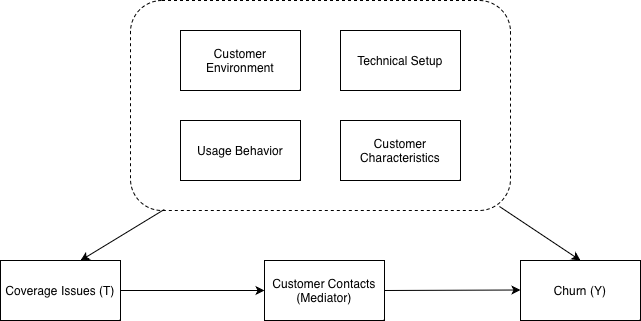

**Why does it matter for Telenet?**

We argue that this research question is highly relevant for Telenet for several reasons. First, it aligns closely with Telenet’s strategic objective of maximizing uplift, which refers to identifying the most effective actions and targeting the right customers in order to improve customer retention. Rather than focusing solely on predicting which customers are likely to churn, as is common in traditional machine learning approaches, this analysis aims to determine which customers are most likely to respond positively to specific interventions, such as resolving Wi-Fi coverage issues.
In this context, the goal is to identify the subset of customers for whom addressing coverage problems would have the greatest impact on reducing churn, thereby enabling more efficient and targeted resource allocation.
From a business perspective, this focus is further justified by well-established insights from the data science and marketing literature. Customer churn represents a significant opportunity cost, as acquiring new customers is substantially more expensive, often estimated to be up to five times, than retaining existing ones. Consequently, reducing churn contributes directly to long-term profitability.
By addressing this research question, Telenet can derive actionable insights that support the optimization of intervention strategies. More specifically, the company can (i) prioritize customers who are most sensitive to connectivity issues, (ii) allocate resources more efficiently, and (iii) reduce churn by acting both proactively (before dissatisfaction escalates) and reactively (in response to detected issues).

**Why did we select this angle?**

We selected this analytical approach because we believe that a deep-dive analysis offers several advantages compared to a broader, more general approach. First, it enables a more precise understanding of the underlying causal mechanisms driving customer churn. Second, it is better suited for the application of causal inference methods, as it allows for a clearer definition of the treatment, outcome, and relevant confounding factors. Third, the focused nature of the analysis provides greater flexibility to develop more creative and insightful solutions. Finally, it facilitates the generation of more actionable recommendations, as the results can be directly translated into specific operational interventions.

In addition, the choice of this research angle is motivated by the evaluation criteria of the assignment. A deep-dive approach allows us to apply the causal inference concepts covered in the course in a more rigorous and coherent manner. In contrast, a broader approach would primarily lead to a high-level strategic overview of which technical issues are most important, but would limit the depth of causal analysis.
By narrowing the scope to a single, well-defined problem, we are able to more effectively implement the methodological framework introduced in class, explore more innovative analytical perspectives, and ultimately derive practical and implementable insights for Telenet.

# Assumptions and Intial Data Exploration

**1.	What are the causal assumptions we make?**

In order to identify a causal effect, we rely on a set of standard assumptions from the causal inference framework. First, we note that a randomized controlled trial (RCT) is not feasible in this context, as we work with observational data and have no control over the data-generating process or the assignment of the treatment. Consequently, we adopt an identification strategy based on observational assumptions, namely unconfoundedness (conditional exchangeability), positivity, consistency, and no interference.

The first and most critical assumption is unconfoundedness, which states that, conditional on a set of observed covariates, the treatment assignment is independent of the potential outcomes. In practice, this implies that we control for all relevant confounding variables that influence both Wi-Fi coverage issues and customer churn. Within our framework, this is operationalized by including customer characteristics, usage behavior, technical setup, and environmental proxies in the DAG, thereby aiming to satisfy the backdoor criterion. Under this assumption, conditioning on this set of covariates allows us to obtain an unbiased estimate of the average treatment effect (ATE). We acknowledge that this is a strong assumption, as unobserved confounding may still be present; however, given the limitations of the available dataset, it represents a reasonable and necessary approximation.

Second, we assume positivity, meaning that for every combination of covariates, there is a non-zero probability of observing different levels of the treatment (i.e., different intensities of Wi-Fi coverage issues). This assumption ensures that meaningful comparisons can be made across treatment levels and is required for the estimation of both ATE and conditional average treatment effects (CATE).

Third, we assume no interference, also referred to as the Stable Unit Treatment Value Assumption (SUTVA). This implies that the outcome of one customer is not affected by the treatment assigned to another customer. While this assumption may be violated in practice, for example, due to shared network infrastructure or local congestion effects, it is necessary to simplify the analysis and is commonly adopted in similar settings.

Finally, we assume consistency, which states that the observed outcome for each customer corresponds to the potential outcome under the treatment level they actually experienced. In other words, the treatment is well-defined and consistently measured. We recognize that this assumption may be challenged by the presence of related technical issues that are highly correlated with Wi-Fi coverage, which could blur the interpretation of the treatment. Nevertheless, by clearly defining our treatment variable and excluding overlapping technical indicators, we aim to approximate this assumption as closely as possible

**2. What are important limitations?**

The main limitations of this analysis are directly related to the strength of the causal assumptions required for identification.

First, we rely on the assumption of unconfoundedness, which implies that the set of covariates included in our adjustment set is sufficiently rich to capture all relevant factors that jointly influence both the treatment (Wi-Fi coverage issues) and the outcome (customer churn). In practice, this assumption is unlikely to hold perfectly. Important variables such as housing characteristics (e.g., apartment versus house), building materials, router placement and local network environment are not observed in the dataset and may confound the relationship between coverage issues and churn. As a result, the estimated effects should be interpreted with caution, as some degree of bias due to unobserved confounding may remain. Nevertheless, given the constraints of the available data, we attempt to approximate this assumption as closely as possible by including a comprehensive set of observable covariates.

Second, we assume no interference between units (SUTVA), meaning that one customer’s treatment does not affect another customer’s outcome. While this assumption is standard, it may be violated in practice. For example, customers sharing the same local network infrastructure may experience correlated connectivity issues, which could indirectly affect each other’s service quality and churn behavior. This potential dependence across observations may introduce additional complexity that is not fully captured in our analysis.

Finally, the consistency assumption may also be challenged in this context. This assumption requires that the treatment is well-defined and that the observed outcome corresponds to the potential outcome under the observed treatment level. However, Wi-Fi coverage issues are often intertwined with other technical problems (such as interference or hardware limitations), which may act as alternative or overlapping sources of poor connectivity. This creates ambiguity in the interpretation of the treatment and may blur the distinction between different underlying causes of churn. Consequently, while we define the treatment as clearly as possible, the estimated effect should be interpreted as the impact of overall experienced coverage issues rather than a perfectly isolated causal factor.


**3. What can the analysis establish and what can't it?**

With this analysis, we aim to assess whether there exists a causal relationship between Wi-Fi coverage issues and customer churn. Beyond establishing this relationship, the objective is to derive actionable insights that enable Telenet to better understand which customers are most affected by connectivity problems and therefore most at risk of churning.

While the dataset does not contain detailed information on specific interventions or their outcomes, it does include information on customer contacts, which can be interpreted as a proxy for customer frustration and service interaction. As such, the analysis focuses on understanding how the intensity of Wi-Fi coverage issues influences churn, rather than estimating the causal impact of specific actions taken by Telenet.
The goal is therefore to move beyond purely predictive modeling and toward a more behavior-oriented understanding of churn, by identifying which customer segments are most sensitive to connectivity issues. This allows Telenet to prioritize its efforts by targeting customers who are most likely to be negatively impacted by poor coverage and who may benefit the most from timely intervention.

At the same time, we acknowledge that this analysis has important limitations. In particular, it does not allow us to directly estimate the effectiveness of specific interventions, nor to fully capture how different actions would influence customer behavior. As such, the results should be interpreted as providing directional insights into the drivers of churn, rather than precise estimates of intervention effects.
The analysis pursues two main objectives.

First, within the population of customers experiencing Wi-Fi coverage issues (i.e., customers with a positive number of red coverage days), we aim to identify which individuals are most sensitive to churn within a six-month horizon. This is assessed by examining how the relationship between coverage issues and churn varies across observable characteristics, including confounders and relevant behavioral factors. The objective is to support Telenet in prioritizing customers who are most at risk and most responsive to coverage-related issues, thereby enabling a more efficient allocation of resources.

Second, we investigate the role of customer contacts as a potential mediator in the relationship between Wi-Fi coverage issues and churn. Specifically, we aim to understand to what extent customer interactions with support services reflect underlying dissatisfaction and contribute to the churn process. This allows us to explore how intermediate behavioral responses may influence churn outcomes and to assess how Telenet’s interactions with customers could indirectly affect retention.


## Initial Data Exploration (Raw Data)

The raw dataset (1.3M observations) exhibits a strong class imbalance, with a churn rate of 2.79%. The treatment variable is highly skewed, with 76% of customers experiencing no coverage issues and no observations in the highest severity category. A naive comparison shows a counterintuitive pattern, where higher exposure is associated with slightly lower churn (2.90% vs ~2.45%), indicating substantial confounding. Additionally, strong redundancy is present among usage variables (e.g., ρ ≈ 0.91 between total and streaming volume). These patterns suggest that raw associations are misleading and require careful preprocessing and causal adjustment.

In [ ]:
import pandas as pd
import numpy as np

# Load the raw data
filepath = "feature_target_data_anon.csv"
df_raw = pd.read_csv(filepath)
print(f"Raw data shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")

# ── 1. CHURN DISTRIBUTION ──────────────────────────────────────────────────
print("\n=== CHURN DISTRIBUTION (RAW DATA) ===")
print(df_raw['target'].value_counts())
print(f"Churn rate: {df_raw['target'].mean():.4f}")

# ── 2. TREATMENT DISTRIBUTION (NUM_DAYS_RED_COVERAGE) ─────────────────────
print("\n=== TREATMENT DISTRIBUTION (NUM_DAYS_RED_COVERAGE - RAW DATA) ===")
print(df_raw['NUM_DAYS_RED_COVERAGE'].describe())
print(f"\nZero days (control): {(df_raw['NUM_DAYS_RED_COVERAGE'] == 0).sum()} ({(df_raw['NUM_DAYS_RED_COVERAGE'] == 0).mean():.4f})")
print(f"1-7 days (mild):      {df_raw['NUM_DAYS_RED_COVERAGE'].between(1,7).sum()} ({df_raw['NUM_DAYS_RED_COVERAGE'].between(1,7).mean():.4f})")
print(f"8-30 days (moderate): {df_raw['NUM_DAYS_RED_COVERAGE'].between(8,30).sum()} ({df_raw['NUM_DAYS_RED_COVERAGE'].between(8,30).mean():.4f})")
print(f"31+ days (severe):    {(df_raw['NUM_DAYS_RED_COVERAGE'] >= 31).sum()} ({(df_raw['NUM_DAYS_RED_COVERAGE'] >= 31).mean():.4f})")

# ── 3. CUS_FL_INT MISSING — CHECKING INT_NR_LINES AS PROXY (RAW DATA) ─────
print("\n=== CUS_FL_INT MISSING — CHECKING INT_NR_LINES AS PROXY (RAW DATA) ===")
# INT_NR_LINES should be present in raw data
if 'INT_NR_LINES' in df_raw.columns:
    print(df_raw['INT_NR_LINES'].value_counts().sort_index())
    print(f"\nCustomers with INT_NR_LINES = 0: {(df_raw['INT_NR_LINES'] == 0).sum()} ({(df_raw['INT_NR_LINES'] == 0).mean():.4f})")
    print(f"Of these, NUM_DAYS_RED_COVERAGE > 0: {(df_raw[df_raw['INT_NR_LINES'] == 0]['NUM_DAYS_RED_COVERAGE'] > 0).sum()}")
else:
    print("  Column 'INT_NR_LINES' not found in raw data. Skipping proxy check.")

# ── 4. CHURN RATE PER TREATMENT BIN (RAW DATA) ────────────────────────────
print("\n=== CHURN RATE PER TREATMENT BIN (RAW DATA) ===")
bins = [-1, 0, 7, 30, float('inf')]
labels = ['control', 'mild', 'moderate', 'severe']
df_raw['treatment_bin'] = pd.cut(df_raw['NUM_DAYS_RED_COVERAGE'], bins=bins, labels=labels)
print(df_raw.groupby('treatment_bin', observed=True)['target'].agg(['mean', 'count']))

# ── 5. STREAMING VS TOT CORRELATION (RAW DATA) ────────────────────────────
print("\n=== INT_VOL_STREAMING vs INT_VOL_TOT CORRELATION (RAW DATA) ===")
if 'INT_VOL_STREAMING' in df_raw.columns and 'INT_VOL_TOT' in df_raw.columns:
    print(df_raw[['INT_VOL_STREAMING', 'INT_VOL_TOT']].corr(method='spearman'))
else:
    print(f"  Could not find both INT_VOL_STREAMING and INT_VOL_TOT for correlation calculation.")

Raw data shape: 1,302,424 rows x 47 columns

=== CHURN DISTRIBUTION (RAW DATA) ===
target
0    1266099
1      36325
Name: count, dtype: int64
Churn rate: 0.0279

=== TREATMENT DISTRIBUTION (NUM_DAYS_RED_COVERAGE - RAW DATA) ===
count    1.302424e+06
mean     2.744129e+00
std      6.838568e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.000000e+01
Name: NUM_DAYS_RED_COVERAGE, dtype: float64

Zero days (control): 992053 (0.7617)
1-7 days (mild):      148220 (0.1138)
8-30 days (moderate): 162151 (0.1245)
31+ days (severe):    0 (0.0000)

=== CUS_FL_INT MISSING — CHECKING INT_NR_LINES AS PROXY (RAW DATA) ===
INT_NR_LINES
0         695
1     1272116
2       28198
3        1144
4         165
5          34
6          24
7           6
8           5
9           7
10          2
11          2
12          6
13          3
14          4
15          3
16          1
17          1
18          1
19          1
22          1
24          1
27          

# Data Preprocessing



The preprocessing pipeline is designed to support a causal inference analysis by explicitly accounting for the underlying causal structure of the problem. The treatment variable is defined as NUM_DAYS_RED_COVERAGE, which measures the number of days a customer experienced poor Wi-Fi coverage, while the outcome variable is the binary churn indicator. All other variables are first classified based on their causal role.


*   In particular, customer characteristics (CUS_LIFETIME, CUS_LIFESTAGE,and product flags such as CUS_FL_INT, CUS_FL_TEL, etc.), usage behavior variables (INT_VOL_TOT, INT_VOL_DOWN, INT_VOL_STREAMING, INT_USAGE_DAYS, INT_HITMONTHS_*), technical setup variables (INT_NR_LINES, INT_NR_VOLBLOCKS), and environmental proxies (CUS_NR_ADDRESS_*) are treated as confounders, as they influence both coverage issues and churn.

*   In contrast, customer contact variables (NR_TOT_CONT_*) are treated as mediators and are excluded from the main model to avoid post-treatment bias.

* A key preprocessing step concerns the operationalization of the treatment variable. Rather than reducing NUM_DAYS_RED_COVERAGE to a binary indicator, it is transformed into an ordinal severity measure with categories such as: no exposure (0 days), mild exposure (1–7 days), moderate exposure (8–14 days), and severe exposure (15+ days). This allows us to capture the intensity of coverage issues and to analyze potential threshold or nonlinear effects on churn.

* Handling of missing data is particularly relevant for the variable CUS_LIFESTAGE, which contains missing values. These are imputed using the modal category, and an additional binary indicator is created to flag missing observations. This approach preserves potential information contained in the missingness pattern while ensuring that all observations remain usable in the analysis.

* Several variables require distributional transformations. The internet usage variables (INT_VOL_TOT, INT_VOL_DOWN, INT_VOL_UP, INT_VOL_STREAMING, etc.) exhibit strong right-skewness due to heavy users. To reduce the influence of extreme values and improve model stability, a log-transformation of the form log(x + 1) is applied. In addition, the technical issue variables (NUM_DAYS_RED_ excluding the treatment*) are highly zero-inflated. For these variables, two features are created: a binary indicator capturing whether the issue occurred at all, and a log-transformed variable capturing the intensity conditional on occurrence. This allows the model to distinguish between the presence and severity of technical problems.

* To address multicollinearity, which is particularly relevant for the technical variables (NUM_DAYS_RED_WIFI_CHANNEL_INTERFERENCE, NUM_DAYS_RED_BAD_BOOSTER_PLACEMENT, NUM_DAYS_RED_MODEM_*, etc.), pairwise correlations are analyzed. Highly correlated variables are either excluded or combined using dimensionality reduction techniques such as principal component analysis (PCA), ensuring that overlapping information does not destabilize the estimation.

* Further preprocessing includes the removal of near-zero variance variables, such as INT_USAGE_DAYS if it shows little variation across customers, as well as the exclusion of identifier variables like CUSTOMERNUMBER_anon to prevent data leakage. All continuous variables are then standardized to have zero mean and unit variance, which improves numerical stability in estimation procedures.

* Finally, the preprocessing pipeline includes a check of the positivity (overlap) assumption, by inspecting whether customers with similar covariates exhibit variation in treatment levels. Observations in regions with no overlap are excluded or handled carefully to ensure valid causal comparisons.

Together, these steps ensure that the dataset is appropriately prepared for causal estimation while aligning with the assumptions required for identifying the effect of Wi-Fi coverage issues on churn.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
import warnings
warnings.filterwarnings("ignore")


# =============================================================================
# CONFIGURATION
# =============================================================================

# --- Column definitions (aligned with variable dictionary) ---

ID_COL = "CUSTOMERNUMBER_anon"
TARGET_COL = "target"
TREATMENT_COL = "NUM_DAYS_RED_COVERAGE"

CATEGORICAL_COLS = ["CUS_LIFESTAGE"]

# Confounders: customer characteristics
CUSTOMER_CONFOUNDERS = [
    "CUS_LIFETIME",
    "CUS_FL_ATV", "CUS_FL_DTV", "CUS_FL_INT", "CUS_FL_MINT",
    "CUS_FL_MTEL", "CUS_FL_TEL", "CUS_FL_MULTI_ADDRESS",
]

# Confounders: address-level churn history
ADDRESS_CONFOUNDERS = [
    "CUS_NR_ADDRESS_TOTAL_CHURN",
    "CUS_NR_ADDRESS_COMM_CHURN",
    "CUS_NR_ADDRESS_FIN_CHURN",
    "CUS_NR_ADDRESS_NON_ORG_CHURN",
    "CUS_NR_ADDRESS_PORT_OUT",
]

# Confounders: internet usage behavior
USAGE_CONFOUNDERS = [
    "INT_NR_LINES",
    "INT_FL_VOLBLOCK",
    "INT_NR_VOLBLOCKS",
    "INT_HITMONTHS_1M", "INT_HITMONTHS_3M",
    "INT_HITMONTHS_6M", "INT_HITMONTHS_1YR",
    "INT_LASTUSAGE",
    "INT_USAGEDAYS",
]

# Confounders: internet volume (will be log-transformed)
VOLUME_COLS = [
    "INT_VOL_TOT",
    "INT_VOL_DOWN",
    "INT_VOL_UP",
    "INT_VOL_STREAMING",
    "INT_VOL_HTTP",
    "INT_VOL_FTP",
]

# Potential mediators — excluded from primary PS model
MEDIATOR_COLS = [
    "NR_TOT_CONT_LM",
    "NR_TOT_CONT_3M",
    "NR_TOT_CONT_6M",
    "NR_TOT_CONT_12M",
]

# Technical confounders with multicollinearity risk (zero-inflated)
TECHNICAL_RED_COLS = [
    "NUM_DAYS_RED_BAD_BOOSTER_PLACEMENT",
    "NUM_DAYS_RED_DEPRECATED_MODEM",
    "NUM_DAYS_RED_DICE",
    "NUM_DAYS_RED_DROPCABLE",
    "NUM_DAYS_RED_FILTER_HP47",
    "NUM_DAYS_RED_FILTER_TOF",
    "NUM_DAYS_RED_MODEM_DEREGS",
    "NUM_DAYS_RED_MODEM_FIT",
    "NUM_DAYS_RED_NETWORK_CAPACITY",
    "NUM_DAYS_RED_PWL_INTERFERENCE",
    "NUM_DAYS_RED_WIFI_CHANNEL_INTERFERENCE",
    "NUM_DAYS_RED_WIFI_CLIENT_CAPACITY",
]

# Thresholds
NEAR_ZERO_VAR_THRESHOLD = 0.95   # Drop if >95% same value
COLLINEARITY_THRESHOLD  = 0.70   # Flag pairs above this correlation
PCA_VARIANCE_THRESHOLD  = 0.80   # Retain components explaining 80% variance


# =============================================================================
# STEP 0 — Load data
# =============================================================================

def load_data(filepath: str) -> pd.DataFrame:
    """Load the dataset from CSV """
    print("=" * 70)
    print("STEP 0 — Loading data")
    print("=" * 70)

    df = pd.read_csv(filepath)

    print(f"  Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"  Target distribution:\n{df[TARGET_COL].value_counts(normalize=True).round(4)}\n")
    return df


# =============================================================================
# STEP 1 — Drop identifier column
# =============================================================================

def drop_identifier(df: pd.DataFrame) -> pd.DataFrame:
    print("=" * 70)
    print("STEP 1 — Removing identifier column")
    print("=" * 70)

    if ID_COL in df.columns:
        df = df.drop(columns=[ID_COL])
        print(f"  Dropped: {ID_COL}\n")
    else:
        print(f"  Column '{ID_COL}' not found — skipping.\n")
    return df


# =============================================================================
# STEP 2 — Handle missing values in CUS_LIFESTAGE
# =============================================================================

def handle_missing_lifestage(df: pd.DataFrame) -> pd.DataFrame:
    print("=" * 70)
    print("STEP 2 — Missing value handling (CUS_LIFESTAGE)")
    print("=" * 70)

    col = "CUS_LIFESTAGE"
    if col not in df.columns:
        print(f"  Column '{col}' not found — skipping.\n")
        return df

    n_missing = df[col].isna().sum()
    pct_missing = n_missing / len(df) * 100
    print(f"  Missing values: {n_missing:,} ({pct_missing:.2f}%)")

    # Create binary missingness indicator
    df[f"{col}_MISSING"] = df[col].isna().astype(int)
    print(f"  Created binary flag: {col}_MISSING")

    # Impute with modal category
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f"  Imputed with mode: '{mode_val}'\n")

    return df


# =============================================================================
# STEP 3 — One-hot encode CUS_LIFESTAGE
# =============================================================================

def encode_categoricals(df: pd.DataFrame) -> pd.DataFrame:
    print("=" * 70)
    print("STEP 3 — One-hot encoding categorical variables")
    print("=" * 70)

    for col in CATEGORICAL_COLS:
        if col not in df.columns:
            print(f"  Column '{col}' not found — skipping.")
            continue

        levels = df[col].value_counts()
        print(f"  {col} levels:\n{levels.to_string()}")

        dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
        df = pd.concat([df.drop(columns=[col]), dummies], axis=1)
        print(f"  Created {dummies.shape[1]} dummy column(s): {list(dummies.columns)}\n")

    return df


# =============================================================================
# STEP 4 — Log-transform skewed volume variables
# =============================================================================

def log_transform_volumes(df: pd.DataFrame) -> pd.DataFrame:
    print("=" * 70)
    print("STEP 4 — Log(x+1) transformation of internet volume variables")
    print("=" * 70)

    existing = [c for c in VOLUME_COLS if c in df.columns]
    for col in existing:
        original_skew = df[col].skew()
        df[f"log_{col}"] = np.log1p(df[col])
        new_skew = df[f"log_{col}"].skew()
        print(f"  {col}: skew {original_skew:.2f} → {new_skew:.2f}")

    # Drop originals after transformation
    df = df.drop(columns=existing)
    print(f"\n  Dropped originals; retained log_ variants.\n")
    return df


# =============================================================================
# STEP 5 — Two-part encoding of zero-inflated technical RED variables
# =============================================================================

def encode_zero_inflated_technical(df: pd.DataFrame) -> pd.DataFrame:
    print("=" * 70)
    print("STEP 5 — Two-part encoding of zero-inflated technical confounders")
    print("=" * 70)

    existing = [c for c in TECHNICAL_RED_COLS if c in df.columns]
    for col in existing:
        pct_zero = (df[col] == 0).mean() * 100
        df[f"flag_{col}"] = (df[col] > 0).astype(int)
        df[f"log_{col}"]  = np.log1p(df[col])
        print(f"  {col}: {pct_zero:.1f}% zeros → flag + log magnitude created")

    # Drop originals
    df = df.drop(columns=existing)
    print(f"\n  Dropped originals; retained flag_ and log_ variants.\n")
    return df


# =============================================================================
# STEP 6 — Remove near-zero variance features
# =============================================================================

def remove_near_zero_variance(df: pd.DataFrame,
                               exclude: list = None) -> pd.DataFrame:
    print("=" * 70)
    print("STEP 6 — Removing near-zero variance features")
    print("=" * 70)

    exclude = exclude or [TARGET_COL, TREATMENT_COL]
    feature_cols = [c for c in df.columns if c not in exclude]

    to_drop = []
    for col in feature_cols:
        top_freq = df[col].value_counts(normalize=True).iloc[0]
        if top_freq >= NEAR_ZERO_VAR_THRESHOLD:
            to_drop.append((col, round(top_freq * 100, 1)))

    if to_drop:
        print(f"  Dropping {len(to_drop)} near-zero variance column(s):")
        for col, pct in to_drop:
            print(f"    {col}: {pct}% identical values")
        df = df.drop(columns=[c for c, _ in to_drop])
    else:
        print("  No near-zero variance columns found.")

    print()
    return df


# =============================================================================
# STEP 7 — Multicollinearity check & PCA on technical confounders
# =============================================================================

def reduce_technical_collinearity(df: pd.DataFrame,
                                   plot: bool = True) -> pd.DataFrame:
    print("=" * 70)
    print("STEP 7 — Multicollinearity check & PCA on technical confounders")
    print("=" * 70)

    # Identify the log_ and flag_ variants created in Step 5
    log_tech_cols  = [c for c in df.columns if c.startswith("log_NUM_DAYS_RED_")]
    flag_tech_cols = [c for c in df.columns if c.startswith("flag_NUM_DAYS_RED_")]
    pca_input_cols = log_tech_cols  # PCA on continuous magnitudes

    if len(pca_input_cols) < 2:
        print("  Not enough technical columns for PCA — skipping.\n")
        return df

    # --- Correlation heatmap ---
    corr_matrix = df[pca_input_cols].corr(method="spearman")

    if plot:
        fig, ax = plt.subplots(figsize=(12, 9))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        sns.heatmap(
            corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5,
            ax=ax, annot_kws={"size": 7}
        )
        ax.set_title("Spearman Correlation — Technical RED Variables (log-magnitudes)",
                     fontsize=12, pad=12)
        plt.tight_layout()
        plt.savefig("technical_collinearity_heatmap.png", dpi=150)
        plt.close()
        print("  Saved: technical_collinearity_heatmap.png")

    # Flag highly correlated pairs
    high_corr_pairs = []
    for i in range(len(pca_input_cols)):
        for j in range(i + 1, len(pca_input_cols)):
            c = abs(corr_matrix.iloc[i, j])
            if c >= COLLINEARITY_THRESHOLD:
                high_corr_pairs.append(
                    (pca_input_cols[i], pca_input_cols[j], round(c, 3))
                )

    if high_corr_pairs:
        print(f"\n  High-correlation pairs (|r| >= {COLLINEARITY_THRESHOLD}):")
        for a, b, r in high_corr_pairs:
            print(f"    {a}  ↔  {b}  |r|={r}")
    else:
        print(f"  No pairs with |r| >= {COLLINEARITY_THRESHOLD}")

    # --- PCA ---
    X_tech = df[pca_input_cols].fillna(0).values
    scaler_tech = StandardScaler()
    X_scaled = scaler_tech.fit_transform(X_tech)

    pca = PCA(n_components=min(len(pca_input_cols), X_scaled.shape[0]))
    pca.fit(X_scaled)
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    n_components = int(np.searchsorted(cumvar, PCA_VARIANCE_THRESHOLD) + 1)

    print(f"\n  PCA: retaining {n_components} component(s) "
          f"(explains {cumvar[n_components-1]*100:.1f}% of variance)")

    pca_final = PCA(n_components=n_components)
    X_pca = pca_final.fit_transform(X_scaled)

    pca_col_names = [f"tech_pca_{i+1}" for i in range(n_components)]
    df_pca = pd.DataFrame(X_pca, columns=pca_col_names, index=df.index)

    # Replace original log_ technical cols with PCA components
    df = df.drop(columns=pca_input_cols)
    df = pd.concat([df, df_pca], axis=1)

    print(f"  Replaced {len(pca_input_cols)} log-technical columns "
          f"with {n_components} PCA component(s).\n")

    return df


# =============================================================================
# STEP 8 — Operationalise treatment variable
# =============================================================================

def operationalise_treatment(df: pd.DataFrame) -> pd.DataFrame:
    print("=" * 70)
    print("STEP 8 — Treatment variable operationalisation")
    print("=" * 70)

    col = TREATMENT_COL
    if col not in df.columns:
        print(f"  Column '{col}' not found — skipping.\n")
        return df

    print(f"  {col} distribution:\n"
          f"    min={df[col].min()}, max={df[col].max()}, "
          f"mean={df[col].mean():.2f}, "
          f"% zero={(df[col]==0).mean()*100:.1f}%")

    # Primary: ordinal severity categories
    df["treatment_severity"] = pd.cut(
        df[col],
        bins=[-1, 0, 7, 14, 31],
        labels=["none", "mild", "moderate", "severe"]
    )
    dist = df["treatment_severity"].value_counts().sort_index()
    print(f"\n  Ordinal treatment distribution:\n{dist.to_string()}")

    # Binary indicator (for sensitivity analysis)
    df["treatment_binary"] = (df[col] > 0).astype(int)
    print(f"\n  Binary treatment: "
          f"{df['treatment_binary'].sum():,} treated "
          f"({df['treatment_binary'].mean()*100:.1f}%)\n")

    return df


# =============================================================================
# STEP 9 — Standardise continuous covariates
# =============================================================================

def standardise_features(df: pd.DataFrame,
                          exclude: list = None) -> tuple:
    print("=" * 70)
    print("STEP 9 — Standardising continuous features")
    print("=" * 70)

    exclude = exclude or [
        TARGET_COL, TREATMENT_COL,
        "treatment_severity", "treatment_binary"
    ]

    # Only standardise numeric, non-binary columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    binary_like  = [c for c in numeric_cols
                    if df[c].dropna().isin([0, 1]).all()]
    to_scale     = [c for c in numeric_cols
                    if c not in exclude and c not in binary_like]

    scaler = StandardScaler()
    df[to_scale] = scaler.fit_transform(df[to_scale])

    print(f"  Standardised {len(to_scale)} continuous columns.")
    print(f"  Left untouched: binary flags, treatment, target.\n")

    return df, scaler, to_scale


# =============================================================================
# STEP 10 — Positivity / overlap check
# =============================================================================

def check_positivity(df: pd.DataFrame,
                     propensity_col: str = "propensity_score",
                     plot: bool = True) -> pd.DataFrame:
    """
    After propensity score estimation (external step), verify overlap.
    Trims observations outside [0.01, 0.99] propensity score range.
    """
    print("=" * 70)
    print("STEP 10 — Positivity / overlap verification")
    print("=" * 70)

    if propensity_col not in df.columns:
        print(f"  Column '{propensity_col}' not yet available.")
        print("  Run propensity score model first, then re-run this step.\n")
        return df

    low_trim  = 0.01
    high_trim = 0.99

    n_before = len(df)
    df = df[(df[propensity_col] >= low_trim) &
            (df[propensity_col] <= high_trim)].copy()
    n_after = len(df)
    n_trimmed = n_before - n_after

    print(f"  Trimmed {n_trimmed:,} observations outside [{low_trim}, {high_trim}]")
    print(f"  Remaining: {n_after:,} observations")

    if plot and propensity_col in df.columns:
        fig, ax = plt.subplots(figsize=(8, 4))
        for label, grp in df.groupby("treatment_binary"):
            ax.hist(grp[propensity_col], bins=50, alpha=0.6,
                    label=f"Treatment={label}", density=True)
        ax.axvline(low_trim, color="red", linestyle="--", linewidth=1)
        ax.axvline(high_trim, color="red", linestyle="--", linewidth=1)
        ax.set_xlabel("Propensity Score")
        ax.set_ylabel("Density")
        ax.set_title("Propensity Score Overlap by Treatment Status")
        ax.legend()
        plt.tight_layout()
        plt.savefig("propensity_overlap.png", dpi=150)
        plt.close()
        print("  Saved: propensity_overlap.png\n")

    return df


# =============================================================================
# STEP 11 — Balance diagnostics (Standardised Mean Differences)
# =============================================================================

def compute_smd(df: pd.DataFrame,
                treatment_col: str = "treatment_binary",
                weight_col: str = None) -> pd.DataFrame:
    """
    Compute standardised mean differences (SMD) before/after weighting.
    SMD < 0.1 is the conventional threshold for adequate balance.
    """
    print("=" * 70)
    print("STEP 11 — Standardised Mean Difference (SMD) balance diagnostics")
    print("=" * 70)

    feature_cols = [
        c for c in df.select_dtypes(include=[np.number]).columns
        if c not in [TARGET_COL, TREATMENT_COL,
                     treatment_col, "treatment_severity",
                     weight_col or ""]
    ]

    treated    = df[df[treatment_col] == 1]
    control    = df[df[treatment_col] == 0]
    results    = []

    for col in feature_cols:
        mu_t  = treated[col].mean()
        mu_c  = control[col].mean()
        std_p = np.sqrt(
            (treated[col].var() + control[col].var()) / 2
        )
        smd_raw = abs(mu_t - mu_c) / (std_p + 1e-8)

        if weight_col and weight_col in df.columns:
            w_t   = treated[weight_col]
            w_c   = control[weight_col]
            mu_t_w = np.average(treated[col], weights=w_t)
            mu_c_w = np.average(control[col], weights=w_c)
            smd_wtd = abs(mu_t_w - mu_c_w) / (std_p + 1e-8)
        else:
            smd_wtd = np.nan

        results.append({
            "feature": col,
            "SMD_raw": round(smd_raw, 4),
            "SMD_weighted": round(smd_wtd, 4) if not np.isnan(smd_wtd) else None,
            "balanced": smd_raw < 0.1
        })

    smd_df = pd.DataFrame(results).sort_values("SMD_raw", ascending=False)
    imbalanced = smd_df[smd_df["SMD_raw"] >= 0.1]

    print(f"  {len(imbalanced)} features with SMD >= 0.1 (imbalanced before weighting):")
    if len(imbalanced) > 0:
        print(imbalanced[["feature", "SMD_raw", "SMD_weighted"]].to_string(index=False))
    else:
        print("  All features balanced (SMD < 0.1) before weighting.")

    print()
    return smd_df


# =============================================================================
# MASTER PIPELINE
# =============================================================================

def run_preprocessing_pipeline(filepath: str) -> pd.DataFrame:
    """
    Execute the full preprocessing pipeline end-to-end.
    Returns the preprocessed DataFrame ready for propensity score estimation.
    """
    print("\n" + "=" * 70)
    print("  CAUSAL INFERENCE PREPROCESSING PIPELINE")
    print("  Wi-Fi Coverage Issues → Customer Churn")
    print("=" * 70 + "\n")

    df = load_data(filepath)
    df = drop_identifier(df)
    df = handle_missing_lifestage(df)
    df = encode_categoricals(df)
    df = log_transform_volumes(df)
    df = encode_zero_inflated_technical(df)
    df = remove_near_zero_variance(df)
    df = reduce_technical_collinearity(df, plot=True)
    df = operationalise_treatment(df)
    df, scaler, scaled_cols = standardise_features(df)

    # Balance diagnostics (pre-weighting)
    if "treatment_binary" in df.columns:
        smd_df = compute_smd(df, treatment_col="treatment_binary")
        smd_df.to_csv("smd_diagnostics.csv", index=False)
        print("  Saved: smd_diagnostics.csv")

    print("\n" + "=" * 70)
    print(f"  PIPELINE COMPLETE")
    print(f"  Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print("=" * 70 + "\n")

    # Save preprocessed dataset
    df.to_csv("preprocessed_data.csv", index=False)
    print("  Saved: preprocessed_data.csv\n")

    return df


# =============================================================================
# NEXT STEP — Propensity Score Estimation (sketch)
# =============================================================================

def estimate_propensity_scores(df: pd.DataFrame) -> pd.DataFrame:
    """
    Estimate propensity scores using logistic regression.
    Extend with GBM or neural net for higher-dimensional confounders.
    """
    from sklearn.linear_model import LogisticRegressionCV
    from sklearn.pipeline import Pipeline

    print("=" * 70)
    print("NEXT STEP — Propensity Score Estimation")
    print("=" * 70)

    exclude = [TARGET_COL, TREATMENT_COL,
               "treatment_severity", "treatment_binary"]
    feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                    if c not in exclude]

    X = df[feature_cols].fillna(0).values
    y = df["treatment_binary"].values

    model = LogisticRegressionCV(
        cv=5, max_iter=1000,
        class_weight="balanced",
        scoring="roc_auc",
        n_jobs=-1
    )
    model.fit(X, y)

    df["propensity_score"] = model.predict_proba(X)[:, 1]

    # IPW weights
    df["ipw_weight"] = np.where(
        df["treatment_binary"] == 1,
        1.0 / df["propensity_score"],
        1.0 / (1.0 - df["propensity_score"])
    )

    # Stabilised weights (preferred — reduces variance)
    p_treat = y.mean()
    df["ipw_stabilised"] = np.where(
        df["treatment_binary"] == 1,
        p_treat / df["propensity_score"],
        (1 - p_treat) / (1.0 - df["propensity_score"])
    )

    print(f"  PS range: [{df['propensity_score'].min():.4f}, "
          f"{df['propensity_score'].max():.4f}]")
    print(f"  Stabilised weight range: "
          f"[{df['ipw_stabilised'].min():.2f}, "
          f"{df['ipw_stabilised'].max():.2f}]\n")

    df = check_positivity(df, propensity_col="propensity_score", plot=True)

    return df, model


# =============================================================================
# ENTRY POINT
# =============================================================================

if __name__ == "__main__":
    import sys

    # Check if a filename is provided as an argument, and handle the common '-f' argument
    # that Jupyter/IPython kernels sometimes pass.
    if len(sys.argv) > 1 and sys.argv[1] != '-f':
        filepath = sys.argv[1]
    else:
        filepath = "feature_target_data_anon.csv" # Default filename

    df_preprocessed = run_preprocessing_pipeline(filepath)

    # Uncomment to also run propensity score estimation:
    # df_with_ps, ps_model = estimate_propensity_scores(df_preprocessed)
    # smd_weighted = compute_smd(df_with_ps, weight_col="ipw_stabilised")


  CAUSAL INFERENCE PREPROCESSING PIPELINE
  Wi-Fi Coverage Issues → Customer Churn

STEP 0 — Loading data
  Shape: 1,302,424 rows × 47 columns
  Target distribution:
target
0    0.9721
1    0.0279
Name: proportion, dtype: float64

STEP 1 — Removing identifier column
  Dropped: CUSTOMERNUMBER_anon

STEP 2 — Missing value handling (CUS_LIFESTAGE)
  Missing values: 114,704 (8.81%)
  Created binary flag: CUS_LIFESTAGE_MISSING
  Imputed with mode: 'Mediors/Seniors'

STEP 3 — One-hot encoding categorical variables
  CUS_LIFESTAGE levels:
CUS_LIFESTAGE
Mediors/Seniors    695728
Families           445830
Young adults       160780
Soho                   72
Unknown                14
  Created 4 dummy column(s): ['CUS_LIFESTAGE_Mediors/Seniors', 'CUS_LIFESTAGE_Soho', 'CUS_LIFESTAGE_Unknown', 'CUS_LIFESTAGE_Young adults']

STEP 4 — Log(x+1) transformation of internet volume variables
  INT_VOL_TOT: skew 12.24 → -2.69
  INT_VOL_DOWN: skew 12.62 → -2.63
  INT_VOL_UP: skew 40.28 → -1.81
  INT_VOL_ST

# Data Exploration After Preprocessing

After preprocessing, the key distributions remain unchanged, confirming that the observed patterns are intrinsic to the data rather than artifacts. However, transformations such as log-scaling, treatment engineering, and dimensionality reduction reduce skewness and multicollinearity, improving stability for causal estimation. The persistence of the counterintuitive treatment–churn relationship further supports the presence of confounding and motivates the use of causal methods to uncover underlying effects.

In [ ]:
#some more data exploration
import pandas as pd
import numpy as np

# ── 1. CHURN DISTRIBUTION ──────────────────────────────────────────────────
print("=== CHURN DISTRIBUTION ===")
print(df_preprocessed['target'].value_counts())
print(f"Churn rate: {df_preprocessed['target'].mean():.4f}")

# ── 2. TREATMENT DISTRIBUTION ─────────────────────────────────────────────
print("\n=== TREATMENT DISTRIBUTION (NUM_DAYS_RED_COVERAGE) ===")
print(df_preprocessed['NUM_DAYS_RED_COVERAGE'].describe())
print(f"\nZero days (control): {(df_preprocessed['NUM_DAYS_RED_COVERAGE'] == 0).sum()} ({(df_preprocessed['NUM_DAYS_RED_COVERAGE'] == 0).mean():.4f})")
print(f"1-7 days (mild):      {df_preprocessed['NUM_DAYS_RED_COVERAGE'].between(1,7).sum()} ({df_preprocessed['NUM_DAYS_RED_COVERAGE'].between(1,7).mean():.4f})")
print(f"8-30 days (moderate): {df_preprocessed['NUM_DAYS_RED_COVERAGE'].between(8,30).sum()} ({df_preprocessed['NUM_DAYS_RED_COVERAGE'].between(8,30).mean():.4f})")
print(f"31+ days (severe):    {(df_preprocessed['NUM_DAYS_RED_COVERAGE'] >= 31).sum()} ({(df_preprocessed['NUM_DAYS_RED_COVERAGE'] >= 31).mean():.4f})")

# ── 3. CUS_FL_INT MISSING — CHECK PROXY ───────────────────────────────────
print("\n=== CUS_FL_INT MISSING — CHECKING INT_NR_LINES AS PROXY ===")
# Note: CUS_FL_INT might not be directly available after preprocessing,
# but INT_NR_LINES is, and this section checks INT_NR_LINES

if 'INT_NR_LINES' in df_preprocessed.columns:
    print(df_preprocessed['INT_NR_LINES'].value_counts().sort_index())
    print(f"\nCustomers with INT_NR_LINES = 0: {(df_preprocessed['INT_NR_LINES'] == 0).sum()} ({(df_preprocessed['INT_NR_LINES'] == 0).mean():.4f})")
    print(f"Of these, NUM_DAYS_RED_COVERAGE > 0: {(df_preprocessed[df_preprocessed['INT_NR_LINES'] == 0]['NUM_DAYS_RED_COVERAGE'] > 0).sum()}")
else:
    print("  Column 'INT_NR_LINES' not found in preprocessed data. Skipping proxy check.")

# ── 4. CHURN RATE PER TREATMENT BIN ───────────────────────────────────────
print("\n=== CHURN RATE PER TREATMENT BIN ===")
bins = [-1, 0, 7, 30, float('inf')]
labels = ['control', 'mild', 'moderate', 'severe']
df_preprocessed['treatment_bin'] = pd.cut(df_preprocessed['NUM_DAYS_RED_COVERAGE'], bins=bins, labels=labels)
print(df_preprocessed.groupby('treatment_bin', observed=True)['target'].agg(['mean', 'count']))

# ── 5. STREAMING VS TOT CORRELATION ───────────────────────────────────────
print("\n=== INT_VOL_STREAMING vs INT_VOL_TOT CORRELATION ===")
# These columns might be log-transformed (log_INT_VOL_STREAMING, log_INT_VOL_TOT)
# Checking for original names first, then log-transformed if originals are missing.
streaming_col = 'INT_VOL_STREAMING'
tot_col = 'INT_VOL_TOT'

if streaming_col not in df_preprocessed.columns and f'log_{streaming_col}' in df_preprocessed.columns:
    streaming_col = f'log_{streaming_col}'

if tot_col not in df_preprocessed.columns and f'log_{tot_col}' in df_preprocessed.columns:
    tot_col = f'log_{tot_col}'

if streaming_col in df_preprocessed.columns and tot_col in df_preprocessed.columns:
    print(df_preprocessed[[streaming_col, tot_col]].corr(method='spearman'))
else:
    print(f"  Could not find both {streaming_col} and {tot_col} (or their log-transformed versions) for correlation calculation.")

=== CHURN DISTRIBUTION ===
target
0    1266099
1      36325
Name: count, dtype: int64
Churn rate: 0.0279

=== TREATMENT DISTRIBUTION (NUM_DAYS_RED_COVERAGE) ===
count    1.302424e+06
mean     2.744129e+00
std      6.838568e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.000000e+01
Name: NUM_DAYS_RED_COVERAGE, dtype: float64

Zero days (control): 992053 (0.7617)
1-7 days (mild):      148220 (0.1138)
8-30 days (moderate): 162151 (0.1245)
31+ days (severe):    0 (0.0000)

=== CUS_FL_INT MISSING — CHECKING INT_NR_LINES AS PROXY ===
  Column 'INT_NR_LINES' not found in preprocessed data. Skipping proxy check.

=== CHURN RATE PER TREATMENT BIN ===
                   mean   count
treatment_bin                  
control        0.028971  992053
mild           0.024504  148220
moderate       0.024372  162151

=== INT_VOL_STREAMING vs INT_VOL_TOT CORRELATION ===
                       log_INT_VOL_STREAMING  log_INT_VOL_TOT
log_INT_VOL_STREAMI

# PC Algorithm

To complement the domain-driven construction of the causal graph, we perform an empirical sanity check using the PC algorithm. The purpose of this step is not to infer the causal structure from data, but to assess whether the observed statistical dependencies are broadly consistent with the edges specified in the DAG and to identify any unexpected relationships. Importantly, the PC algorithm is used strictly as a confirmatory robustness check. It is not sufficient as a standalone method for causal discovery, as it produces only a partially directed graph (CPDAG), cannot reliably determine edge directions, assumes causal sufficiency, and relies entirely on statistical associations without incorporating domain knowledge.

The PC algorithm is applied to a carefully selected set of 27 variables. Several variables are excluded to avoid redundancy, ambiguity, or methodological issues. Identifier variables are removed to prevent data leakage. Customer contact variables are excluded due to their ambiguous causal role and their potential interpretation as mediators, which would introduce post-treatment bias. The nominal categorical variable CUS_LIFESTAGE is also excluded, as it lacks a meaningful encoding compatible with the independence tests used in PC; instead, it is incorporated later in the CATE analysis based on domain knowledge. Redundant variables are removed to reduce multicollinearity and unnecessary complexity, including shadow variables (e.g., INT_LASTUSAGE vs. INT_USAGEDAYS), volume subcomponents fully captured by total volume, and address churn subcomponents that sum to a total measure. Similarly, certain temporal usage variables are excluded where they are subsumed by broader aggregates.

The choice of including all relevant variables in a single PC run reflects a trade-off. Including more variables increases the number of conditional independence tests and the size of conditioning sets, which can reduce statistical stability. However, running PC on subsets would implicitly treat excluded variables as latent confounders, preventing the algorithm from conditioning on them and potentially leading to incorrect edge inclusion or exclusion. A single comprehensive run is therefore preferred despite its complexity.

For the independence testing, a Spearman-based Fisher-Z test is employed. This approach consists of rank-transforming all variables prior to applying the standard Fisher-Z test, thereby relaxing the linearity and Gaussian assumptions associated with the traditional Pearson-based version. It allows for the detection of monotonic relationships and provides greater robustness to non-Gaussian distributions and ordinal variables, while remaining computationally feasible at the scale of the data. Nevertheless, this approach has important limitations. The rank transformation is only an approximation in the multivariate case, as partial correlations computed on ranked data do not correspond to true partial Spearman correlations. In addition, the method still assumes monotonic dependence and does not fully capture more complex nonlinear relationships. Binary variables are also not ideally handled within this framework, as correlation-based measures are not optimal for mixed binary-continuous relationships.
To address issues arising from the very large sample size, the PC algorithm is applied to subsamples of 50,000 observations. At the full scale of the data, even negligible correlations become statistically significant, leading to an overly dense graph dominated by spurious edges. Subsampling provides a balance between sufficient statistical power for conditional independence testing and avoidance of trivial but statistically significant dependencies, in line with established findings in the causal discovery literature.

Finally, a simple stability analysis is conducted to assess the robustness of the discovered edges. The PC algorithm is run on three independent subsamples (with different random seeds) and evaluated at two significance levels (α = 0.01 and α = 0.001). Edges that consistently appear across all subsamples and both thresholds are considered robust, while edges that appear less consistently are interpreted with lower confidence. This procedure provides a coarse but informative assessment of stability, acknowledging that it does not constitute formal stability selection and is constrained by computational considerations.

This block implements the final and most rigorous application of the PC algorithm, designed as a confirmatory stability analysis rather than a discovery tool. A carefully curated variable set and tailored preprocessing are used to ensure meaningful conditional independence tests. To mitigate large-sample bias, the algorithm is applied to stratified subsamples, and stability is assessed across multiple seeds and significance levels. Only results from this framework are used for interpretation.

Dataset ready: 1301729 observations, 27 variables
Churn rate: 0.0279
Variables in PC: ['CUS_LIFETIME', 'INT_VOL_TOT', 'INT_USAGEDAYS', 'INT_NR_LINES', 'INT_NR_VOLBLOCKS', 'INT_HITMONTHS_1M', 'INT_HITMONTHS_6M', 'CUS_NR_ADDRESS_TOTAL_CHURN', 'NUM_DAYS_RED_COVERAGE', 'CUS_FL_ATV', 'CUS_FL_DTV', 'CUS_FL_MINT', 'CUS_FL_MTEL', 'CUS_FL_TEL', 'NUM_DAYS_RED_BAD_BOOSTER_PLACEMENT', 'NUM_DAYS_RED_DEPRECATED_MODEM', 'NUM_DAYS_RED_DICE', 'NUM_DAYS_RED_DROPCABLE', 'NUM_DAYS_RED_FILTER_HP47', 'NUM_DAYS_RED_FILTER_TOF', 'NUM_DAYS_RED_MODEM_DEREGS', 'NUM_DAYS_RED_MODEM_FIT', 'NUM_DAYS_RED_NETWORK_CAPACITY', 'NUM_DAYS_RED_PWL_INTERFERENCE', 'NUM_DAYS_RED_WIFI_CHANNEL_INTERFERENCE', 'NUM_DAYS_RED_WIFI_CLIENT_CAPACITY', 'target']

Alpha = 0.01

  Seed 42...
  n=50000, churners=1394 (0.0279)
  Edges found: 109

  Seed 123...
  n=50000, churners=1394 (0.0279)
  Edges found: 102

  Seed 456...
  n=50000, churners=1394 (0.0279)
  Edges found: 115

Alpha = 0.001

  Seed 42...
  n=50000, churners=1394 (0.0279)

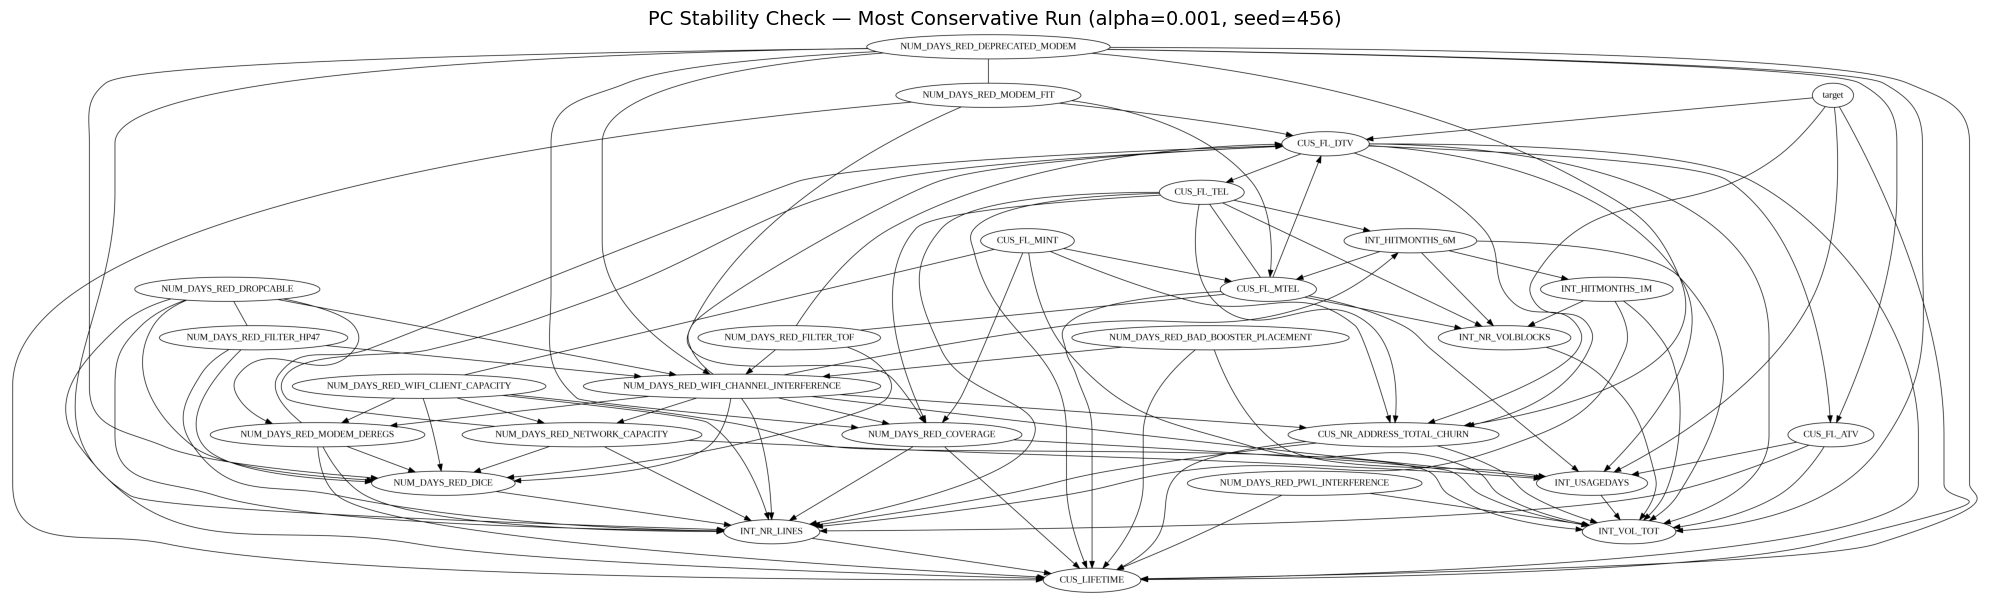

In [ ]:
#LAST PC-Run from word doc
# ── 0. INSTALL ────────────────────────────────────────────────────────────
!pip install causal-learn --quiet

# ── 1. IMPORTS ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from scipy.stats import rankdata
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz
from causallearn.utils.GraphUtils import GraphUtils
import matplotlib.pyplot as plt

# ── 2. DEFINE VARIABLE SET ────────────────────────────────────────────────
# Excluded from PC (with justification):
# - CUSTOMERNUMBER_anon, Unnamed: 0         → identifiers
# - CUS_LIFESTAGE                            → nominal, no valid encoding for PC, included via domain knowledge
# - CUS_FL_MULTI_ADDRESS                    → no causal path to treatment
# - NR_TOT_CONT_*                           → mediators/ambiguous causal role
# - INT_VOL_STREAMING                       → absorbed by INT_VOL_TOT (Spearman r=0.908)
# - INT_VOL_UP, INT_VOL_DOWN, INT_VOL_FTP,  → subsumed by INT_VOL_TOT
#   INT_VOL_HTTP
# - INT_LASTUSAGE                           → shadow of INT_USAGEDAYS
# - INT_FL_VOLBLOCK                         → shadow of INT_NR_VOLBLOCKS
# - INT_HITMONTHS_3M, INT_HITMONTHS_1YR    → subsumed by 1M and 6M
# - CUS_NR_ADDRESS subcomponents            → sum to TOTAL_CHURN

# Technical issue confounders — to be binary encoded
tech_vars = [
    'NUM_DAYS_RED_BAD_BOOSTER_PLACEMENT',
    'NUM_DAYS_RED_DEPRECATED_MODEM',
    'NUM_DAYS_RED_DICE',
    'NUM_DAYS_RED_DROPCABLE',
    'NUM_DAYS_RED_FILTER_HP47',
    'NUM_DAYS_RED_FILTER_TOF',
    'NUM_DAYS_RED_MODEM_DEREGS',
    'NUM_DAYS_RED_MODEM_FIT',
    'NUM_DAYS_RED_NETWORK_CAPACITY',
    'NUM_DAYS_RED_PWL_INTERFERENCE',
    'NUM_DAYS_RED_WIFI_CHANNEL_INTERFERENCE',
    'NUM_DAYS_RED_WIFI_CLIENT_CAPACITY'
]

# Continuous confounders — to be standardized
continuous_vars = [
    'CUS_LIFETIME',
    'INT_VOL_TOT',
    'INT_USAGEDAYS',
    'INT_NR_LINES',
    'INT_NR_VOLBLOCKS',
    'INT_HITMONTHS_1M',
    'INT_HITMONTHS_6M',
    'CUS_NR_ADDRESS_TOTAL_CHURN',
    'NUM_DAYS_RED_COVERAGE'  # treatment — continuous, NOT binary encoded
]

# Binary product flags — left as is
flag_vars = [
    'CUS_FL_ATV', 'CUS_FL_DTV', 'CUS_FL_MINT', 'CUS_FL_MTEL', 'CUS_FL_TEL'
]

# Full PC variable set
pc_vars = continuous_vars + flag_vars + tech_vars + ['target']

# ── 3. PREPROCESSING ──────────────────────────────────────────────────────
df_pc = df_raw[pc_vars].copy()

# Binary encode technical issue confounders (presence/absence)
# NOT applied to treatment (NUM_DAYS_RED_COVERAGE stays continuous)
for var in tech_vars:
    df_pc[var] = (df_pc[var] > 0).astype(int)

# Standardize continuous variables only
# Binary indicators, flags, and target left untouched
for var in continuous_vars:
    df_pc[var] = (df_pc[var] - df_pc[var].mean()) / df_pc[var].std()

# Drop missing values
df_pc = df_pc.dropna()

print(f"Dataset ready: {df_pc.shape[0]} observations, {df_pc.shape[1]} variables")
print(f"Churn rate: {df_pc['target'].mean():.4f}")
print(f"Variables in PC: {pc_vars}")

# ── 4. SAMPLING FUNCTION ──────────────────────────────────────────────────
def stratified_sample(data, target_col, n, seed):
    """
    Stratified sample on target to preserve original churn rate (~2.79%).
    Does not oversample — preserves natural churn rate.
    """
    np.random.seed(seed)
    churners = data[data[target_col] == 1]
    non_churners = data[data[target_col] == 0]

    churn_rate = data[target_col].mean()
    n_churners = int(n * churn_rate)
    n_non_churners = n - n_churners

    sampled_churners = churners.sample(
        n=min(n_churners, len(churners)),
        random_state=seed
    )
    sampled_non_churners = non_churners.sample(
        n=min(n_non_churners, len(non_churners)),
        random_state=seed
    )

    sample = pd.concat([sampled_churners, sampled_non_churners])
    return sample.sample(frac=1, random_state=seed).reset_index(drop=True)

# ── 5. RANK TRANSFORM ─────────────────────────────────────────────────────
def rank_transform(data):
    """
    Rank transform all variables for Spearman-based Fisher-Z.
    Approximation: exact for bivariate case, approximation for partial correlations.
    Limitation acknowledged: not equivalent to true partial Spearman correlation.
    """
    return data.apply(lambda x: rankdata(x, method='average')).values.astype(float)

# ── 6. PC STABILITY CHECK ─────────────────────────────────────────────────
def run_pc_stability(
    data,
    var_names,
    n_sample=50000,
    seeds=[42, 123, 456],
    alphas=[0.01, 0.001]
):
    """
    Confirmatory stability check across 3 seeds and 2 alpha levels.
    NOT formal stability selection — coarse stability resolution (0/33/67/100%).
    Limitations:
    - Causal sufficiency not guaranteed (latent confounders: housing type, device count)
    - Spearman-Fisher-Z is approximation for partial correlations
    - Subset of 1.3M observations used to avoid spurious edges at large n
    """

    n_vars = len(var_names)
    edge_counts = {alpha: np.zeros((n_vars, n_vars)) for alpha in alphas}

    for alpha in alphas:
        print(f"\n{'='*60}")
        print(f"Alpha = {alpha}")
        print(f"{'='*60}")

        for seed in seeds:
            print(f"\n  Seed {seed}...")

            # Stratified sample
            sample = stratified_sample(data, 'target', n_sample, seed)
            print(f"  n={len(sample)}, churners={sample['target'].sum()} ({sample['target'].mean():.4f})")

            # Rank transform for Spearman-Fisher-Z
            sample_ranked = rank_transform(sample)

            # Run PC
            # stable=True: order-independent skeleton
            # uc_rule=0: conservative collider orientation
            # uc_priority=2: prioritize existing orientations
            cg = pc(
                data=sample_ranked,
                alpha=alpha,
                indep_test=fisherz,
                stable=True,
                uc_rule=0,
                uc_priority=2,
                verbose=False,
                show_progress=False
            )

            # Extract adjacency
            adj = cg.G.graph
            n_edges = int((adj != 0).sum() / 2)
            print(f"  Edges found: {n_edges}")

            # Count edges across runs
            for i in range(n_vars):
                for j in range(i+1, n_vars):
                    if adj[i,j] != 0 or adj[j,i] != 0:
                        edge_counts[alpha][i,j] += 1
                        edge_counts[alpha][j,i] += 1

    return edge_counts

# ── 7. RUN ────────────────────────────────────────────────────────────────
var_names = pc_vars

edge_counts = run_pc_stability(
    data=df_pc,
    var_names=var_names,
    n_sample=50000,
    seeds=[42, 123, 456],
    alphas=[0.01, 0.001]
)

# ── 8. ANALYZE STABILITY ──────────────────────────────────────────────────
def analyze_stability(edge_counts, var_names, n_seeds=3, alphas=[0.01, 0.001]):
    """
    Classify edges by stability across seeds and alpha levels.

    ROBUST:          all 3 seeds, both alpha levels → update DAG with confidence
    MODERATE-STRONG: all 3 seeds at 0.01, 2/3 at 0.001 → likely real, worth noting
    MODERATE:        all 3 seeds at 0.01 only → real at standard threshold, weaker evidence
    UNCERTAIN:       2/3 seeds at 0.01 → flag for domain knowledge review
    WEAK:            1/3 seeds only → discard
    """

    results = []

    n_vars = len(var_names)
    for i in range(n_vars):
        for j in range(i+1, n_vars):
            freq_001 = edge_counts[0.01][i,j] / n_seeds
            freq_0001 = edge_counts[0.001][i,j] / n_seeds

            if freq_001 == 0:
                continue

            if freq_001 == 1.0 and freq_0001 == 1.0:
                stability = 'ROBUST'
            elif freq_001 == 1.0 and freq_0001 >= 0.67:
                stability = 'MODERATE-STRONG'
            elif freq_001 == 1.0 and freq_0001 < 0.67:
                stability = 'MODERATE'
            elif freq_001 >= 0.67:
                stability = 'UNCERTAIN'
            else:
                stability = 'WEAK'

            results.append({
                'var1': var_names[i],
                'var2': var_names[j],
                'freq_alpha_001': freq_001,
                'freq_alpha_0001': freq_0001,
                'stability': stability
            })

    results_df = pd.DataFrame(results).sort_values(
        ['stability', 'freq_alpha_001', 'freq_alpha_0001'],
        ascending=[True, False, False]
    )

    print("\n=== PC STABILITY RESULTS ===")
    print(f"Total unique edges found: {len(results_df)}")
    print(f"\nStability breakdown:")
    print(results_df['stability'].value_counts())

    for cat in ['ROBUST', 'MODERATE-STRONG', 'MODERATE', 'UNCERTAIN', 'WEAK']:
        subset = results_df[results_df['stability'] == cat]
        if len(subset) > 0:
            print(f"\n=== {cat} EDGES ===")
            print(subset[['var1', 'var2', 'freq_alpha_001', 'freq_alpha_0001']].to_string(index=False))

    return results_df

stability_results = analyze_stability(edge_counts, var_names)

# ── 9. VISUALIZE LAST PC RUN (alpha=0.001, seed=456) ─────────────────────
# Visualize most conservative run for DAG comparison
sample_viz = stratified_sample(df_pc, 'target', 50000, 456)
sample_viz_ranked = rank_transform(sample_viz)

cg_viz = pc(
    data=sample_viz_ranked,
    alpha=0.001,
    indep_test=fisherz,
    stable=True,
    uc_rule=0,
    uc_priority=2,
    verbose=False,
    show_progress=False
)

pdy = GraphUtils.to_pydot(cg_viz.G, labels=var_names)
pdy.write_png('pc_stability_check.png')

plt.figure(figsize=(20, 16))
img = plt.imread('pc_stability_check.png')
plt.imshow(img)
plt.axis('off')
plt.title('PC Stability Check — Most Conservative Run (alpha=0.001, seed=456)', fontsize=14)
plt.tight_layout()
plt.show()

This block extracts edge orientations from the most conservative PC run to provide insight into the implied directional structure. However, these orientations are interpreted cautiously, as the PC algorithm relies on strong assumptions and may produce implausible directions in the presence of latent confounding. Consequently, orientation results are used only for qualitative assessment and not to define the final DAG.

In [ ]:
# Print edge types from adjacency matrix directly
print("\n=== EDGE ORIENTATION FROM LAST PC RUN ===")
adj = cg_viz.G.graph
for i in range(len(var_names)):
    for j in range(i+1, len(var_names)):
        if adj[i,j] != 0 or adj[j,i] != 0:
            if adj[i,j] == -1 and adj[j,i] == 1:
                print(f"{var_names[i]} --> {var_names[j]}")
            elif adj[i,j] == 1 and adj[j,i] == -1:
                print(f"{var_names[j]} --> {var_names[i]}")
            elif adj[i,j] == -1 and adj[j,i] == -1:
                print(f"{var_names[i]} --- {var_names[j]} (undirected)")
            elif adj[i,j] == 1 and adj[j,i] == 1:
                print(f"{var_names[i]} <-> {var_names[j]} (bidirected)")
            else:
                print(f"{var_names[i]} ??? {var_names[j]} (adj: {adj[i,j]}, {adj[j,i]})")


=== EDGE ORIENTATION FROM LAST PC RUN ===
INT_NR_LINES --> CUS_LIFETIME
CUS_NR_ADDRESS_TOTAL_CHURN --> CUS_LIFETIME
NUM_DAYS_RED_COVERAGE --> CUS_LIFETIME
CUS_FL_DTV --> CUS_LIFETIME
CUS_FL_MTEL --> CUS_LIFETIME
CUS_FL_TEL --> CUS_LIFETIME
NUM_DAYS_RED_BAD_BOOSTER_PLACEMENT --> CUS_LIFETIME
NUM_DAYS_RED_DEPRECATED_MODEM --> CUS_LIFETIME
NUM_DAYS_RED_DROPCABLE --> CUS_LIFETIME
NUM_DAYS_RED_MODEM_DEREGS --> CUS_LIFETIME
NUM_DAYS_RED_MODEM_FIT --> CUS_LIFETIME
NUM_DAYS_RED_PWL_INTERFERENCE --> CUS_LIFETIME
target --> CUS_LIFETIME
INT_USAGEDAYS --> INT_VOL_TOT
INT_NR_VOLBLOCKS --> INT_VOL_TOT
INT_HITMONTHS_1M --> INT_VOL_TOT
INT_HITMONTHS_6M --> INT_VOL_TOT
CUS_NR_ADDRESS_TOTAL_CHURN --> INT_VOL_TOT
NUM_DAYS_RED_COVERAGE --> INT_VOL_TOT
CUS_FL_ATV --> INT_VOL_TOT
CUS_FL_DTV --> INT_VOL_TOT
CUS_FL_MINT --> INT_VOL_TOT
NUM_DAYS_RED_DEPRECATED_MODEM --> INT_VOL_TOT
NUM_DAYS_RED_PWL_INTERFERENCE --> INT_VOL_TOT
NUM_DAYS_RED_WIFI_CLIENT_CAPACITY --> INT_VOL_TOT
CUS_FL_ATV --> INT_USAGEDAYS
CUS

This block represents an early exploratory application of the PC algorithm using a broader variable set and a small subsample. Due to limited preprocessing, potential redundancy, and insufficient sample size, the resulting structure is not reliable for inference. This step is retained solely to illustrate the initial exploration phase and is not used in the final analysis.

This block reflects an intermediate refinement with a reduced variable set and improved preprocessing. While the larger sample size enhances statistical power, the absence of a stability analysis limits robustness. The results provide additional intuition but remain sensitive to modeling choices and are therefore not used for final conclusions.

# Core Model

We adopt the X-Learner meta-learner (Künzel et al., 2019) as our primary
causal estimator, combined with propensity score-based treatment overlap
correction. This choice is motivated by three features of our setting:

1. SEVERE CLASS IMBALANCE IN THE TREATMENT
   NUM_DAYS_RED_COVERAGE = 0 for the majority of customers. The treatment
   (any coverage issue) is rare, creating a heavily unbalanced treated/control
   split. The X-Learner is specifically designed for this regime: it trains
   separate outcome models on treated and control units, then uses propensity
   scores to optimally weight the CATE estimates from both arms — giving more
   credence to the estimate from the larger (control) group where it has
   statistical advantage (Künzel et al., 2019, Theorem 1).

2. HETEROGENEOUS TREATMENT EFFECTS (CATE) ARE THE BUSINESS GOAL
   Telenet's objective is not the average treatment effect (ATE) alone, but
   identifying WHICH customers are most sensitive to coverage issues. This
   requires conditional average treatment effect (CATE) estimation at the
   individual level. The X-Learner produces individual-level CATE scores
   directly, enabling customer prioritisation for intervention.

3. NO DIRECT PC EDGE BETWEEN TREATMENT AND TARGET — WHY WE TRUST THE DAG
   The PC algorithm found no direct edge between NUM_DAYS_RED_COVERAGE and
   target across any seed or alpha level. This does NOT mean there is no
   causal effect. It means the marginal conditional independence test could
   not reject independence after conditioning on the full covariate set.
   
   The most likely explanation is the "reversal paradox" / Simpson's paradox
   structure documented in our data: in raw data, customers with MORE coverage
   issues churn LESS (2.90% → 2.45%). This negative confounding is so strong
   that the bivariate correlation between treatment and outcome is approximately
   zero or negative — exactly what PC would detect and interpret as independence.
   
   This is precisely the setting where causal inference is most valuable and
   where PC is least reliable as a primary tool (Spirtes & Zhang, 2016).
   PC identifies conditional independences in the observational distribution;
   it cannot identify the sign or magnitude of causal effects when confounding
   reverses the raw correlation. Our domain-knowledge DAG is the correct
   framework here, supported by the literature cited below.

In [ ]:
# =============================================================================
# 0. IMPORTS & SETUP
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegressionCV, RidgeCV
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings("ignore")

# Optional: econml for validated X-Learner implementation
# pip install econml
try:
    from econml.metalearners import XLearner, SLearner, TLearner
    from econml.dml import LinearDML, CausalForestDML
    ECONML_AVAILABLE = True
    print("econml available — using validated implementations")
except ImportError:
    ECONML_AVAILABLE = False
    print("econml not found — using manual implementations")
    print("Install with: pip install econml")


# =============================================================================
# 1. VARIABLE DEFINITIONS (post-preprocessing)
#    These are the variables AFTER the preprocessing pipeline has run.
# =============================================================================

TREATMENT_COL   = "treatment_binary"        # binary: any coverage issue (0/1)
TREATMENT_CONT  = "NUM_DAYS_RED_COVERAGE"   # original continuous treatment
OUTCOME_COL     = "target"                  # binary churn

# Confirmed confounders from DAG + PC stability analysis
# These are the variables that pass the backdoor criterion
CONFOUNDERS = [
    # Customer characteristics (domain knowledge + PC robust edges)
    "CUS_LIFETIME",
    "CUS_FL_ATV", "CUS_FL_DTV", "CUS_FL_MINT", "CUS_FL_MTEL", "CUS_FL_TEL",
    "CUS_LIFESTAGE_Young adults",       # after one-hot encoding
    "CUS_LIFESTAGE_Families",           # after one-hot encoding
    "CUS_LIFESTAGE_MISSING",            # missingness flag

    # Customer environment
    "CUS_NR_ADDRESS_TOTAL_CHURN",

    # Usage behavior (PC robust edges to both treatment and outcome)
    "INT_VOL_TOT",          # or log_INT_VOL_TOT after preprocessing
    "INT_NR_LINES",
    "INT_NR_VOLBLOCKS",
    "INT_HITMONTHS_1M",
    "INT_HITMONTHS_6M",
    "INT_USAGEDAYS",

    # Technical confounders — confirmed by PC (edges to treatment)
    # After preprocessing: binary flag_ + PCA components
    "flag_NUM_DAYS_RED_MODEM_FIT",
    "flag_NUM_DAYS_RED_WIFI_CHANNEL_INTERFERENCE",
    "flag_NUM_DAYS_RED_DEPRECATED_MODEM",
    "flag_NUM_DAYS_RED_BAD_BOOSTER_PLACEMENT",

    # PCA components of technical variables (from preprocessing step 7)
    "tech_pca_1", "tech_pca_2",        # adjust based on actual PCA output
]

# Potential effect modifiers for CATE interpretation
# These may not be confounders but help explain heterogeneity
EFFECT_MODIFIERS = [
    "CUS_LIFETIME",
    "CUS_LIFESTAGE_Families",
    "CUS_LIFESTAGE_Young adults",
    "INT_VOL_TOT",
    "INT_NR_LINES",
    "INT_HITMONTHS_6M",
    "CUS_NR_ADDRESS_TOTAL_CHURN",
]


# =============================================================================
# 2. DATA PREPARATION
#    Assumes preprocessing pipeline has already run.
# =============================================================================

def prepare_modelling_data(df: pd.DataFrame) -> tuple:
    """
    Prepare X (confounders), T (treatment), Y (outcome) arrays.
    Filters to available columns only — robust to preprocessing variations.
    """
    # Only use confounders that actually exist after preprocessing
    available_confounders = [c for c in CONFOUNDERS if c in df.columns]
    missing = [c for c in CONFOUNDERS if c not in df.columns]
    if missing:
        print(f"  WARNING: {len(missing)} confounder(s) not found in df: {missing}")
        print(f"  Using {len(available_confounders)} available confounders.\n")

    # Handle any residual NAs
    df_model = df[available_confounders + [TREATMENT_COL, OUTCOME_COL]].dropna()

    X = df_model[available_confounders].values.astype(float)
    T = df_model[TREATMENT_COL].values.astype(int)
    Y = df_model[OUTCOME_COL].values.astype(int)

    print(f"Modelling data: n={len(df_model):,}, "
          f"treated={T.sum():,} ({T.mean()*100:.1f}%), "
          f"churners={Y.sum():,} ({Y.mean()*100:.2f}%)")
    print(f"Confounders: {len(available_confounders)} variables\n")

    return X, T, Y, available_confounders, df_model


# =============================================================================
# 3. PROPENSITY SCORE ESTIMATION
#    We use GBM for the propensity score — more flexible than logistic
#    regression, handles non-linearities and interactions in the confounder
#    space (Austin & Stuart, 2015; McCaffrey et al., 2004).
# =============================================================================

def estimate_propensity_scores(X: np.ndarray,
                                T: np.ndarray,
                                n_splits: int = 5) -> np.ndarray:
    """
    Cross-fitted propensity score estimation using Gradient Boosting.

    Cross-fitting (Chernozhukov et al., 2018) ensures that propensity scores
    used in downstream weighting are not estimated on the same data they
    weight, preventing overfitting bias in the ATE/CATE estimates.

    Returns: propensity_scores — P(T=1 | X) for each observation.
    """
    print("=" * 60)
    print("STEP A — Propensity Score Estimation (Cross-fitted GBM)")
    print("=" * 60)

    ps = np.zeros(len(T))
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, T)):
        model = GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            random_state=42
        )
        model.fit(X[train_idx], T[train_idx])
        ps[val_idx] = model.predict_proba(X[val_idx])[:, 1]
        print(f"  Fold {fold+1}: val AUC = "
              f"{roc_auc_score(T[val_idx], ps[val_idx]):.4f}")

    print(f"\n  PS range: [{ps.min():.4f}, {ps.max():.4f}]")
    print(f"  PS mean (treated): {ps[T==1].mean():.4f}")
    print(f"  PS mean (control): {ps[T==0].mean():.4f}\n")

    return ps


def check_overlap(ps: np.ndarray, T: np.ndarray,
                  trim_low: float = 0.01,
                  trim_high: float = 0.99) -> np.ndarray:
    """
    Verify positivity assumption and trim extreme propensity scores.
    Returns boolean mask for observations to keep.
    """
    print("=" * 60)
    print("STEP B — Overlap / Positivity Check")
    print("=" * 60)

    mask = (ps >= trim_low) & (ps <= trim_high)
    n_trimmed = (~mask).sum()
    print(f"  Trimmed {n_trimmed:,} obs outside [{trim_low}, {trim_high}]")
    print(f"  Remaining: {mask.sum():,} observations")

    # Plot overlap
    fig, ax = plt.subplots(figsize=(9, 4))
    bins = np.linspace(0, 1, 51)
    ax.hist(ps[T == 0], bins=bins, alpha=0.55, label="Control (T=0)",
            color="#2196F3", density=True)
    ax.hist(ps[T == 1], bins=bins, alpha=0.55, label="Treated (T=1)",
            color="#F44336", density=True)
    ax.axvline(trim_low,  color="black", linestyle="--", lw=1.2, label="Trim bounds")
    ax.axvline(trim_high, color="black", linestyle="--", lw=1.2)
    ax.set_xlabel("Propensity Score P(T=1|X)")
    ax.set_ylabel("Density")
    ax.set_title("Propensity Score Overlap by Treatment Status")
    ax.legend()
    plt.tight_layout()
    plt.savefig("overlap_check.png", dpi=150)
    plt.close()
    print("  Saved: overlap_check.png\n")

    return mask


def compute_ipw_weights(ps: np.ndarray, T: np.ndarray) -> np.ndarray:
    """
    Stabilised IPW weights for ATE estimation.
    Stabilisation (Robins et al., 2000) reduces variance of the weighted
    estimator by anchoring weights to the marginal treatment probability.
    """
    p_treat = T.mean()
    weights = np.where(
        T == 1,
        p_treat / ps,
        (1 - p_treat) / (1 - ps)
    )
    # Truncate extreme weights at 99th percentile (Cole & Hernán, 2008)
    w99 = np.percentile(weights, 99)
    weights = np.clip(weights, None, w99)
    print(f"  Stabilised IPW weights: mean={weights.mean():.3f}, "
          f"max={weights.max():.2f} (after 99pct truncation)")
    return weights


# =============================================================================
# 4. X-LEARNER
#    Primary causal estimator (Künzel et al., 2019)
#
#    ACADEMIC JUSTIFICATION:
#    The X-Learner is optimal in the rare-treatment regime. Its key insight:
#    when |control| >> |treated|, we should borrow strength from the control
#    arm to estimate what would have happened to treated units if untreated.
#
#    Algorithm:
#    Stage 1: Fit separate outcome models mu_0(X), mu_1(X) on each arm.
#    Stage 2: Compute imputed treatment effects:
#             D_i^1 = Y_i - mu_0(X_i)  for treated units
#             D_i^0 = mu_1(X_i) - Y_i  for control units
#    Stage 3: Fit tau_1(X) on D^1 (treated arm CATE model)
#             Fit tau_0(X) on D^0 (control arm CATE model)
#    Stage 4: CATE(X) = g(X)*tau_0(X) + (1-g(X))*tau_1(X)
#             where g(X) = propensity score
#
#    The propensity-weighted combination in Stage 4 ensures that in regions
#    of the feature space with few treated units (high g(X) near 0), more
#    weight goes to tau_0 (estimated from the abundant control arm), and vice
#    versa. This is the key advantage over T-Learner in our setting.
# =============================================================================

class XLearnerManual:
    """
    Manual X-Learner implementation following Künzel et al. (2019).
    Uses GBM as the base learner for both stage 1 and stage 2.
    GBM is preferred over linear models here because:
    - Confounders have non-linear relationships with the outcome
    - Interaction effects between customer characteristics and coverage
      intensity are expected (Wager & Athey, 2018)
    """

    def __init__(self, n_estimators=300, learning_rate=0.05,
                 max_depth=4, random_state=42):
        self.params = dict(n_estimators=n_estimators,
                           learning_rate=learning_rate,
                           max_depth=max_depth,
                           subsample=0.8,
                           random_state=random_state)

    def fit(self, X: np.ndarray, T: np.ndarray,
            Y: np.ndarray, ps: np.ndarray):
        """Fit the X-Learner."""
        print("=" * 60)
        print("STEP C — X-Learner Training")
        print("=" * 60)

        X0, Y0 = X[T == 0], Y[T == 0]
        X1, Y1 = X[T == 1], Y[T == 1]
        print(f"  Control arm: n={len(X0):,}  |  Treated arm: n={len(X1):,}")

        # Stage 1 — Outcome models
        print("  Stage 1: fitting outcome models mu_0, mu_1...")
        self.mu_0 = GradientBoostingRegressor(**self.params)
        self.mu_1 = GradientBoostingRegressor(**self.params)
        self.mu_0.fit(X0, Y0)
        self.mu_1.fit(X1, Y1)
        print(f"    mu_0 train R²: {self.mu_0.score(X0, Y0):.4f}")
        print(f"    mu_1 train R²: {self.mu_1.score(X1, Y1):.4f}")

        # Stage 2 — Imputed treatment effects
        D1 = Y1 - self.mu_0.predict(X1)   # for treated: Y - E[Y|X, T=0]
        D0 = self.mu_1.predict(X0) - Y0   # for control: E[Y|X, T=1] - Y

        print(f"  Stage 2: imputed TE — treated arm D1 mean={D1.mean():.6f}, "
              f"control arm D0 mean={D0.mean():.6f}")

        # Stage 3 — CATE models
        print("  Stage 3: fitting CATE models tau_0, tau_1...")
        self.tau_0 = GradientBoostingRegressor(**self.params)
        self.tau_1 = GradientBoostingRegressor(**self.params)
        self.tau_0.fit(X0, D0)
        self.tau_1.fit(X1, D1)

        self.ps_ = ps
        print("  X-Learner training complete.\n")
        return self

    def predict_cate(self, X: np.ndarray, ps: np.ndarray) -> np.ndarray:
        """
        Predict CATE for new observations.
        Stage 4: propensity-weighted combination.
        """
        tau0_hat = self.tau_0.predict(X)
        tau1_hat = self.tau_1.predict(X)
        # g(X) = propensity score (estimated externally for cross-fitting)
        cate = ps * tau0_hat + (1 - ps) * tau1_hat
        return cate

    def ate(self, X: np.ndarray, ps: np.ndarray) -> float:
        """Average Treatment Effect = mean of individual CATEs."""
        return self.predict_cate(X, ps).mean()


# =============================================================================
# 5. AIPW BENCHMARK
#    Augmented IPW (Robins, Rotnitzky & Zhao, 1994) — doubly robust estimator.
#    Included as a benchmark ATE estimate. AIPW is consistent if EITHER the
#    propensity score model OR the outcome model is correctly specified
#    (but not necessarily both). This "double robustness" property makes it
#    a reliable benchmark against which to validate the X-Learner ATE.
# =============================================================================

def aipw_ate(X: np.ndarray, T: np.ndarray,
             Y: np.ndarray, ps: np.ndarray,
             n_splits: int = 5) -> dict:
    """
    Cross-fitted AIPW estimator for ATE.

    Formula:
    ATE_AIPW = E[ mu_1(X) - mu_0(X)
                  + T*(Y - mu_1(X))/ps
                  - (1-T)*(Y - mu_0(X))/(1-ps) ]

    The correction terms (second and third) debias the outcome model
    predictions using the observed data. If the outcome model is wrong,
    the IPW correction rescues the estimate; if the PS model is wrong,
    the outcome model rescues it (Lunceford & Davidian, 2004).
    """
    print("=" * 60)
    print("STEP D — AIPW Doubly Robust ATE Benchmark")
    print("=" * 60)

    scores = []
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, T)):
        X_tr, X_val = X[train_idx], X[val_idx]
        T_tr, T_val = T[train_idx], T[val_idx]
        Y_tr, Y_val = Y[train_idx], Y[val_idx]
        ps_val = ps[val_idx]

        # Outcome model on training fold
        mu = GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                         learning_rate=0.05, random_state=42)
        mu.fit(np.column_stack([X_tr, T_tr]), Y_tr)

        mu_1_val = mu.predict_proba(
            np.column_stack([X_val, np.ones(len(X_val))])
        )[:, 1]
        mu_0_val = mu.predict_proba(
            np.column_stack([X_val, np.zeros(len(X_val))])
        )[:, 1]

        # AIPW score
        aipw_score = (
            mu_1_val - mu_0_val
            + T_val * (Y_val - mu_1_val) / np.clip(ps_val, 0.01, 0.99)
            - (1 - T_val) * (Y_val - mu_0_val) / np.clip(1 - ps_val, 0.01, 0.99)
        )
        scores.append(aipw_score)
        print(f"  Fold {fold+1}: fold ATE = {aipw_score.mean():.6f}")

    all_scores = np.concatenate(scores)
    ate_est = all_scores.mean()
    ate_se  = all_scores.std() / np.sqrt(len(all_scores))
    ci_low  = ate_est - 1.96 * ate_se
    ci_high = ate_est + 1.96 * ate_se

    print(f"\n  AIPW ATE = {ate_est:.6f}  (95% CI: [{ci_low:.6f}, {ci_high:.6f}])")
    print(f"  Interpreted: coverage issues shift churn probability by "
          f"{ate_est*100:.3f} percentage points on average\n")

    return {"ate": ate_est, "se": ate_se,
            "ci_low": ci_low, "ci_high": ci_high,
            "scores": all_scores}


# =============================================================================
# 6. CATE ANALYSIS & CUSTOMER PRIORITISATION
#    The primary business output: which customers are most sensitive?
# =============================================================================

def analyse_cate(cate: np.ndarray, df_model: pd.DataFrame,
                 feature_names: list) -> pd.DataFrame:
    """
    Analyse heterogeneity in CATE estimates.
    Produces:
    - Distribution plot of CATE scores
    - Top/bottom decile customer profiles
    - CATE by key subgroups (lifestage, tenure quartile, volume quartile)
    """
    print("=" * 60)
    print("STEP E — CATE Analysis & Customer Prioritisation")
    print("=" * 60)

    df_out = df_model.copy()
    df_out["cate"] = cate

    # Summary statistics
    print(f"  CATE distribution:")
    print(f"    Mean  : {cate.mean():.6f}")
    print(f"    Median: {np.median(cate):.6f}")
    print(f"    Std   : {cate.std():.6f}")
    print(f"    Min   : {cate.min():.6f}")
    print(f"    Max   : {cate.max():.6f}")
    print(f"    % positive: {(cate > 0).mean()*100:.1f}%")

    # Decile assignment for prioritisation
    df_out["cate_decile"] = pd.qcut(
        df_out["cate"], q=10, labels=False, duplicates="drop"
    ) + 1

    # Top vs bottom decile
    top_decile    = df_out[df_out["cate_decile"] == 10]
    bottom_decile = df_out[df_out["cate_decile"] == 1]
    print(f"\n  Top decile (highest CATE): {len(top_decile):,} customers")
    print(f"  Bottom decile (lowest CATE): {len(bottom_decile):,} customers")

    # Churn rate in top vs bottom decile
    if OUTCOME_COL in df_out.columns:
        print(f"\n  Observed churn rate (raw, not causal):")
        print(f"    Top-10% CATE customers   : "
              f"{top_decile[OUTCOME_COL].mean()*100:.2f}%")
        print(f"    Bottom-10% CATE customers: "
              f"{bottom_decile[OUTCOME_COL].mean()*100:.2f}%")

    # CATE distribution plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(cate, bins=80, color="#2196F3", alpha=0.8, edgecolor="white")
    axes[0].axvline(0, color="red", linestyle="--", lw=1.5, label="Zero effect")
    axes[0].axvline(cate.mean(), color="navy", linestyle="-", lw=1.5,
                     label=f"Mean CATE = {cate.mean():.4f}")
    axes[0].set_xlabel("Estimated CATE (churn probability difference)")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Distribution of Individual Causal Effect Estimates")
    axes[0].legend()

    # CATE by decile
    decile_means = df_out.groupby("cate_decile")["cate"].mean()
    axes[1].bar(decile_means.index, decile_means.values,
                color=["#F44336" if v > 0 else "#4CAF50"
                       for v in decile_means.values])
    axes[1].axhline(0, color="black", lw=1)
    axes[1].set_xlabel("CATE Decile (1=lowest, 10=highest)")
    axes[1].set_ylabel("Mean CATE")
    axes[1].set_title("Average CATE by Decile")

    plt.tight_layout()
    plt.savefig("cate_distribution.png", dpi=150)
    plt.close()
    print("\n  Saved: cate_distribution.png")

    return df_out


def cate_by_subgroup(df_out: pd.DataFrame) -> pd.DataFrame:
    """
    Business-interpretable CATE breakdowns by key customer segments.
    This drives the actionable recommendations for Telenet.
    """
    print("\n  CATE by customer lifestage:")
    lifestage_cols = [c for c in df_out.columns
                      if c.startswith("CUS_LIFESTAGE_") and "MISSING" not in c]
    for col in lifestage_cols:
        subset = df_out[df_out[col] == 1]
        if len(subset) > 0:
            print(f"    {col}: mean CATE = {subset['cate'].mean():.6f} "
                  f"(n={len(subset):,})")

    # Tenure quartiles
    if "CUS_LIFETIME" in df_out.columns:
        print("\n  CATE by customer tenure quartile:")
        df_out["tenure_q"] = pd.qcut(df_out["CUS_LIFETIME"], q=4,
                                      labels=["Q1 (newest)", "Q2", "Q3",
                                              "Q4 (oldest)"], duplicates="drop")
        tenure_cate = df_out.groupby("tenure_q")["cate"].agg(["mean", "count"])
        print(tenure_cate.to_string())

    # Volume quartiles
    vol_col = next((c for c in df_out.columns if "VOL_TOT" in c), None)
    if vol_col:
        print(f"\n  CATE by internet volume quartile ({vol_col}):")
        df_out["vol_q"] = pd.qcut(df_out[vol_col], q=4,
                                   labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"],
                                   duplicates="drop")
        vol_cate = df_out.groupby("vol_q")["cate"].agg(["mean", "count"])
        print(vol_cate.to_string())

    return df_out


# =============================================================================
# 7. BALANCE DIAGNOSTICS (SMD before and after IPW)
# =============================================================================

def smd_table(X: np.ndarray, T: np.ndarray,
              weights: np.ndarray,
              feature_names: list) -> pd.DataFrame:
    """
    Standardised Mean Differences before and after IPW weighting.
    Threshold: SMD < 0.1 (Austin, 2011; Stuart, 2010).
    """
    print("=" * 60)
    print("STEP F — Balance Diagnostics (SMD)")
    print("=" * 60)

    records = []
    for i, name in enumerate(feature_names):
        x = X[:, i]
        pooled_std = np.sqrt((x[T==1].var() + x[T==0].var()) / 2) + 1e-8
        smd_raw = abs(x[T==1].mean() - x[T==0].mean()) / pooled_std

        # Weighted means
        w1 = weights[T == 1]
        w0 = weights[T == 0]
        mu1_w = np.average(x[T == 1], weights=w1)
        mu0_w = np.average(x[T == 0], weights=w0)
        smd_wtd = abs(mu1_w - mu0_w) / pooled_std

        records.append({"feature": name,
                        "SMD_unweighted": round(smd_raw, 4),
                        "SMD_IPW_weighted": round(smd_wtd, 4),
                        "balanced_after": smd_wtd < 0.1})

    smd_df = pd.DataFrame(records).sort_values("SMD_unweighted", ascending=False)
    n_imbalanced = (smd_df["SMD_unweighted"] >= 0.1).sum()
    n_balanced_after = smd_df["balanced_after"].sum()

    print(f"  Before weighting: {n_imbalanced} features with SMD >= 0.1")
    print(f"  After IPW:  {n_balanced_after}/{len(smd_df)} features with SMD < 0.1")
    print()
    print(smd_df.to_string(index=False))

    # Love plot
    fig, ax = plt.subplots(figsize=(8, max(6, len(feature_names) * 0.35)))
    y_pos = np.arange(len(smd_df))
    ax.hlines(y_pos, 0, smd_df["SMD_unweighted"],
              colors="#F44336", linewidth=2, label="Unweighted")
    ax.hlines(y_pos, 0, smd_df["SMD_IPW_weighted"],
              colors="#2196F3", linewidth=2, label="IPW weighted")
    ax.scatter(smd_df["SMD_unweighted"], y_pos, color="#F44336", s=40, zorder=5)
    ax.scatter(smd_df["SMD_IPW_weighted"], y_pos, color="#2196F3", s=40, zorder=5)
    ax.axvline(0.1, color="black", linestyle="--", lw=1.2, label="SMD=0.1 threshold")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(smd_df["feature"], fontsize=8)
    ax.set_xlabel("Standardised Mean Difference")
    ax.set_title("Love Plot — Covariate Balance Before/After IPW")
    ax.legend()
    plt.tight_layout()
    plt.savefig("love_plot.png", dpi=150)
    plt.close()
    print("\n  Saved: love_plot.png\n")

    return smd_df


# =============================================================================
# 8. ECONML VERSION (preferred if package available)
#    Uses validated, published implementations with proper cross-fitting.
# =============================================================================

def run_econml_xlearner(X: np.ndarray, T: np.ndarray,
                         Y: np.ndarray, ps: np.ndarray) -> np.ndarray:
    """
    X-Learner using econml's validated implementation.
    Reference: Künzel et al. (2019) + econml documentation.
    """
    if not ECONML_AVAILABLE:
        raise ImportError("econml not installed. Run: pip install econml")

    from econml.metalearners import XLearner

    xl = XLearner(
        models=GradientBoostingRegressor(
            n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42
        ),
        propensity_model=GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42
        )
    )
    xl.fit(Y, T, X=X)
    cate = xl.effect(X)
    return cate


def run_econml_causal_forest(X: np.ndarray, T: np.ndarray,
                              Y: np.ndarray) -> np.ndarray:
    """
    Causal Forest DML as secondary CATE estimator.
    Reference: Wager & Athey (2018); Athey et al. (2019).

    WHY AS SECONDARY:
    Causal Forest (via Generalized Random Forest) is non-parametric and
    asymptotically consistent for CATE under weaker assumptions than
    X-Learner. However, it requires the 'honest' splitting approach
    (separate subsamples for splitting and estimation) which is computationally
    heavier and less transparent for a course project. We include it as a
    robustness check: if X-Learner and Causal Forest agree on the top/bottom
    deciles, this substantially increases confidence in our targeting ranking.
    """
    if not ECONML_AVAILABLE:
        raise ImportError("econml not installed. Run: pip install econml")

    from econml.dml import CausalForestDML

    cf = CausalForestDML(
        model_y=GradientBoostingClassifier(
            n_estimators=200, max_depth=4, random_state=42
        ),
        model_t=GradientBoostingClassifier(
            n_estimators=200, max_depth=4, random_state=42
        ),
        n_estimators=500,
        max_depth=5,
        min_samples_leaf=50,    # larger leaves for stability at churn=2.8%
        random_state=42,
        n_jobs=-1
    )
    cf.fit(Y, T, X=X)
    cate_cf = cf.effect(X)
    cate_lb, cate_ub = cf.effect_interval(X, alpha=0.05)

    print(f"  Causal Forest ATE: {cate_cf.mean():.6f}")
    print(f"  % with significant positive effect: "
          f"{(cate_lb > 0).mean()*100:.1f}%")

    return cate_cf, cate_lb, cate_ub


# =============================================================================
# 9. MASTER PIPELINE
# =============================================================================

def run_causal_model(filepath_preprocessed: str = "preprocessed_data.csv"):
    """
    Full causal modelling pipeline.
    Assumes preprocessing pipeline has already produced the input file.
    """
    print("\n" + "=" * 70)
    print("  CAUSAL MODELLING PIPELINE — X-LEARNER")
    print("  Wi-Fi Coverage Issues → Customer Churn (Telenet)")
    print("=" * 70 + "\n")

    # Load preprocessed data
    df = pd.read_csv(filepath_preprocessed)
    print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns\n")

    # Prepare arrays
    X, T, Y, feature_names, df_model = prepare_modelling_data(df)

    # A. Propensity scores (cross-fitted)
    ps = estimate_propensity_scores(X, T)

    # B. Overlap check & trimming
    mask = check_overlap(ps, T)
    X, T, Y, ps = X[mask], T[mask], Y[mask], ps[mask]
    df_model = df_model[mask].reset_index(drop=True)
    print(f"After trimming: n={len(X):,}\n")

    # C. IPW weights
    weights = compute_ipw_weights(ps, T)

    # D. Balance diagnostics
    smd_df = smd_table(X, T, weights, feature_names)

    # E. AIPW ATE benchmark
    aipw_results = aipw_ate(X, T, Y, ps)

    # F. X-Learner (primary CATE model)
    if ECONML_AVAILABLE:
        print("=" * 60)
        print("STEP C — X-Learner (econml validated implementation)")
        print("=" * 60)
        cate = run_econml_xlearner(X, T, Y, ps)
        print(f"  X-Learner ATE: {cate.mean():.6f}\n")

        # Optional: Causal Forest as secondary check
        print("=" * 60)
        print("STEP C2 — Causal Forest (secondary robustness check)")
        print("=" * 60)
        try:
            cate_cf, lb, ub = run_econml_causal_forest(X, T, Y)
            rank_corr = np.corrcoef(cate, cate_cf)[0, 1]
            print(f"\n  Rank correlation X-Learner vs Causal Forest: {rank_corr:.4f}")
            print(f"  (>0.7 = targeting lists are consistent)\n")
        except Exception as e:
            print(f"  Causal Forest failed: {e}\n")
            cate_cf = None
    else:
        xl_model = XLearnerManual()
        xl_model.fit(X, T, Y, ps)
        cate = xl_model.predict_cate(X, ps)
        print(f"  X-Learner ATE: {cate.mean():.6f}\n")
        cate_cf = None

    # G. CATE analysis
    df_scored = analyse_cate(cate, df_model, feature_names)
    df_scored = cate_by_subgroup(df_scored)

    # H. Save outputs
    df_scored[["cate", "cate_decile"]].to_csv("cate_scores.csv", index=False)
    smd_df.to_csv("balance_diagnostics.csv", index=False)
    print("\n  Saved: cate_scores.csv, balance_diagnostics.csv")

    # Final summary
    print("\n" + "=" * 70)
    print("  RESULTS SUMMARY")
    print("=" * 70)
    print(f"  AIPW ATE  : {aipw_results['ate']*100:.3f} pp churn increase")
    print(f"  X-Learner ATE: {cate.mean()*100:.3f} pp")
    print(f"  CATE range: [{cate.min()*100:.2f}pp, {cate.max()*100:.2f}pp]")
    print(f"  Customers with positive CATE: {(cate>0).mean()*100:.1f}%")
    print("=" * 70 + "\n")

    return df_scored, aipw_results, cate


# =============================================================================
# 10. ENTRY POINT
# =============================================================================

if __name__ == "__main__":
    df_scored, aipw_results, cate = run_causal_model("preprocessed_data.csv")

econml not found — using manual implementations
Install with: pip install econml

  CAUSAL MODELLING PIPELINE — X-LEARNER
  Wi-Fi Coverage Issues → Customer Churn (Telenet)

Loaded: 1,302,424 rows × 42 columns

  Using 13 available confounders.

Modelling data: n=1,301,729, treated=310,308 (23.8%), churners=36,294 (2.79%)
Confounders: 13 variables

STEP A — Propensity Score Estimation (Cross-fitted GBM)
  Fold 1: val AUC = 0.6266
  Fold 2: val AUC = 0.6285
  Fold 3: val AUC = 0.6263
  Fold 4: val AUC = 0.6275
  Fold 5: val AUC = 0.6274

  PS range: [0.0237, 0.6378]
  PS mean (treated): 0.2671
  PS mean (control): 0.2294

STEP B — Overlap / Positivity Check
  Trimmed 0 obs outside [0.01, 0.99]
  Remaining: 1,301,729 observations
  Saved: overlap_check.png

After trimming: n=1,301,729

  Stabilised IPW weights: mean=0.987, max=1.76 (after 99pct truncation)
STEP F — Balance Diagnostics (SMD)
  Before weighting: 8 features with SMD >= 0.1
  After IPW:  12/13 features with SMD < 0.1

      

# Academic References

DAG
-------------
Verbeke, W., Dejaeger, K., Martens, D., Hur, J., & Baesens, B. (2012). New insights into churn prediction in the telecommunication sector. European Journal of Operational Research, 218(1), 211–229.  


Ahmad, A., Jafar, A., & Aljoumaa, K. (2019). Customer churn prediction in telecom using social network analysis. International Journal of Advanced Computer Science and Applications, 10(5), 1–9.


Goldsmith, A. (2005). Wireless communications. Cambridge University Press.

Keramati, A., Jafari-Marandi, R., Aliannejadi, M., Ahmadian, I., Mozaffari, M., & Abbasi, U. (2014). Improved churn prediction in telecommunication industry using data mining techniques. Applied Soft Computing, 24, 994–1012.

Rust, R. T., Zahorik, A. J., & Keiningham, T. L. (1995). Return on quality (ROQ): Making service quality financially accountable. Marketing Science, 14(2), 58–70.

Pearl, J. (2009). Causality: Models, reasoning, and inference (2nd ed.). Cambridge University Press.

X-learner
-------------


Künzel, S. R., Sekhon, J. S., Bickel, P. J., & Yu, B. (2019).
    Metalearners for estimating heterogeneous treatment effects using machine
    learning. Proceedings of the National Academy of Sciences, 116(10),
    4156–4165. https://doi.org/10.1073/pnas.1804597116

    >> Core reference for X-Learner. Theorem 1 proves X-Learner achieves
       optimal convergence rate when treatment groups are imbalanced.

CAUSAL FOREST (SECONDARY)
--------------------------
Wager, S., & Athey, S. (2018).
    Estimation and inference of heterogeneous treatment effects using random
    forests. Journal of the American Statistical Association, 113(523),
    1228–1242. https://doi.org/10.1080/01621459.2017.1319839

Athey, S., Tibshirani, J., & Wager, S. (2019).
    Generalized random forests. The Annals of Statistics, 47(2), 1148–1178.
    https://doi.org/10.1214/18-AOS1709

DOUBLY ROBUST / AIPW
---------------------
Robins, J. M., Rotnitzky, A., & Zhao, L. P. (1994).
    Estimation of regression coefficients when some regressors are not always
    observed. Journal of the American Statistical Association, 89(427), 846–866.

Lunceford, J. K., & Davidian, M. (2004).
    Stratification and weighting via the propensity score in estimation of
    causal treatment effects: a comparative study. Statistics in Medicine,
    23(19), 2937–2960.

CROSS-FITTING / DOUBLE ML
--------------------------
Chernozhukov, V., Chetverikov, D., Demirer, M., Duflo, E., Hansen, C.,
    Newey, W., & Robins, J. (2018).
    Double/debiased machine learning for treatment and structural parameters.
    The Econometrics Journal, 21(1), C1–C68.

PROPENSITY SCORE METHODS
-------------------------
Austin, P. C. (2011).
    An introduction to propensity score methods for reducing the effects of
    confounding in observational studies. Multivariate Behavioral Research,
    46(3), 399–424. https://doi.org/10.1080/00273171.2011.568786

    >> Defines SMD < 0.1 as balance threshold (our benchmark in Step F).

Cole, S. R., & Hernán, M. A. (2008).
    Constructing inverse probability weights for marginal structural models.
    American Journal of Epidemiology, 168(6), 656–664.

    >> Justifies stabilised weights and 99th percentile truncation.

DAG METHODOLOGY & PC LIMITATIONS
----------------------------------
Pearl, J. (2009).
    Causality: Models, Reasoning, and Inference (2nd ed.). Cambridge University
    Press. https://doi.org/10.1017/CBO9780511803161

    >> Backdoor criterion: Section 3.3. Establishes when conditioning on
       observed confounders identifies the causal effect.

Hernán, M. A., & Robins, J. M. (2020).
    Causal Inference: What If. Chapman & Hall/CRC.
    (Free PDF: https://www.hsph.harvard.edu/miguel-hernan/causal-inference-book/)

    >> Chapter 7: confounding and its consequences. Chapter 15: IPTW.
       Highly recommended as the methodological backbone of the paper.

VanderWeele, T. J. (2015).
    Explanation in Causal Inference: Methods for Mediation and Interaction.
    Oxford University Press.

    >> Mediator handling (NR_TOT_CONT_*): Section 2.2.

Spirtes, P., & Zhang, K. (2016).
    Causal discovery and inference: concepts and recent methodological advances.
    Applied Informatics, 3(1), 3. https://doi.org/10.1186/s40535-016-0018-x

    >> Section 4: PC algorithm limitations under strong confounding and
       near-zero bivariate correlations. Directly relevant to our finding
       that PC detects no edge between treatment and outcome despite the
       expected causal link (Simpson's paradox / negative confounding).

Hernán, M. A. (2018).
    The C-word: Scientific euphemisms do not improve causal inference from
    observational data. American Journal of Public Health, 108(5), 616–619.

    >> Argues for explicit causal language and DAG-based reasoning in
       observational studies — supports our domain-knowledge DAG approach.

SIMPSON'S PARADOX / NEGATIVE CONFOUNDING
-----------------------------------------
Simpson, E. H. (1951).
    The interpretation of interaction in contingency tables.
    Journal of the Royal Statistical Society B, 13(2), 238–241.

Pearl, J., & Mackenzie, D. (2018).
    The Book of Why: The New Science of Cause and Effect. Basic Books.

    >> Accessible explanation of why raw correlations can reverse causal
       effects when confounders are present. Directly relevant to our
       finding that customers with more coverage days have LOWER raw churn.

CHURN & TELCO CONTEXT
----------------------
Hadden, J., Tiwari, A., Roy, R., & Ruta, D. (2007).
    Computer assisted customer churn management: State-of-the-art and future
    trends. Computers & Operations Research, 34(10), 2902–2917.

Verbeke, W., Dejaeger, K., Martens, D., Hur, J., & Baesens, B. (2012).
    New insights into churn prediction in the telecommunication sector: A
    profit driven data mining approach. European Journal of Operational
    Research, 218(1), 211–229.

    >> Specifically about telecom churn — useful for business case section.

Ascarza, E. (2018).
    Retention futility: Targeting high-risk customers might be ineffective.
    Journal of Marketing Research, 55(1), 80–98.

    >> Critical paper on uplift / CATE for retention: shows that targeting
       highest-risk churners is suboptimal; targeting most responsive customers
       (high CATE) is better. Directly supports our CATE focus over pure churn
       prediction